In [154]:
# ============================================================
# Import Required Libraries
# ============================================================

import re
import json
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")

Libraries imported successfully.


In [155]:
# ============================================================
# Load Dataset
# ============================================================

DATASET_PATH = Path("context_augmented_dataset.jsonl")

df = pd.read_json(DATASET_PATH, lines=True)

# Create a working copy
working_df = copy.deepcopy(df)

print("Dataset loaded successfully.")
print(f"Original Dataset Shape : {df.shape}")
print(f"Working Copy Shape     : {working_df.shape}")

Dataset loaded successfully.
Original Dataset Shape : (2751, 11)
Working Copy Shape     : (2751, 11)


In [156]:
print("Working copy identical to original:", df.equals(working_df))

Working copy identical to original: True


### 1.1 Dataset Structure Validation
This step verifies that the loaded dataset conforms to the expected structure before any preprocessing operations are applied.

The following properties are validated:
- Dataset dimensions
- Dataset schema (column names)
- Data types of each feature

In [157]:
# ============================================================
# Step 1.1 - Dataset Structure Validation
# ============================================================

print("=" * 80)
print("DATASET STRUCTURE VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# Dataset Shape
# ------------------------------------------------------------

rows, cols = working_df.shape

print(f"Total Samples  : {rows}")
print(f"Total Features : {cols}")

# ------------------------------------------------------------
# Dataset Schema
# ------------------------------------------------------------

schema = pd.DataFrame({
    "Column Name": working_df.columns,
    "Data Type": working_df.dtypes.astype(str).values
})

print("\nDataset Schema")

display(schema)

# ------------------------------------------------------------
# Expected Schema Validation
# ------------------------------------------------------------

expected_columns = [
    "id",
    "test_id",
    "isFlaky",
    "issue_category",
    "repo_url",
    "issue_commit",
    "fixed_commit",
    "test_code",
    "helper_methods_json",
    "failure_log",
    "code_under_test_json"
]

missing_columns = list(set(expected_columns) - set(working_df.columns))
extra_columns = list(set(working_df.columns) - set(expected_columns))

print("\nSchema Validation")
print("-" * 40)

if not missing_columns and not extra_columns:
    print("✓ Dataset schema matches the expected structure.")
else:
    if missing_columns:
        print("Missing Columns:", missing_columns)

    if extra_columns:
        print("Unexpected Columns:", extra_columns)

DATASET STRUCTURE VALIDATION
Total Samples  : 2751
Total Features : 11

Dataset Schema


,Column Name,Data Type
0,id,int64
1,test_id,str
2,isFlaky,int64
3,issue_category,str
4,repo_url,str
5,issue_commit,str
6,fixed_commit,str
7,test_code,str
8,helper_methods_json,object
9,failure_log,str



Schema Validation
----------------------------------------
✓ Dataset schema matches the expected structure.


### 1.2 Data Integrity Validation
This step evaluates the integrity and consistency of the dataset before preprocessing begins.

The following validation checks are performed:
- Missing value analysis
- Duplicate test identifier analysis
- Target label distribution analysis.

In [158]:
# ============================================================
# Step 1.2 - Data Integrity Validation
# ============================================================

print("=" * 80)
print("DATA INTEGRITY VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Missing Value Analysis
# ------------------------------------------------------------

print("\n1. Missing Value Analysis")
print("-" * 50)

missing = working_df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing (%)": ((missing.values / len(working_df)) * 100).round(2)
})

display(missing_df)

# ------------------------------------------------------------
# 2. Duplicate Test Identifier Analysis
# ------------------------------------------------------------

print("\n2. Duplicate Test Identifier Analysis")
print("-" * 50)

duplicate_test_ids = working_df.duplicated(subset=["test_id"]).sum()

print(f"Duplicate Test IDs : {duplicate_test_ids}")

# ------------------------------------------------------------
# 3. Target Label Distribution
# ------------------------------------------------------------

print("\n3. Target Label Distribution")
print("-" * 50)

label_counts = (
    working_df["isFlaky"]
    .value_counts()
    .sort_index()
)

label_df = pd.DataFrame({
    "Class": ["Non-Flaky (0)", "Flaky (1)"],
    "Count": label_counts.values,
    "Percentage (%)": (
        label_counts.values / len(working_df) * 100
    ).round(2)
})

display(label_df)

DATA INTEGRITY VALIDATION

1. Missing Value Analysis
--------------------------------------------------


,Column,Missing Values,Missing (%)
0,id,0,0.0
1,test_id,0,0.0
2,isFlaky,0,0.0
3,issue_category,0,0.0
4,repo_url,0,0.0
5,issue_commit,0,0.0
6,fixed_commit,0,0.0
7,test_code,0,0.0
8,helper_methods_json,0,0.0
9,failure_log,0,0.0



2. Duplicate Test Identifier Analysis
--------------------------------------------------
Duplicate Test IDs : 0

3. Target Label Distribution
--------------------------------------------------


,Class,Count,Percentage (%)
0,Non-Flaky (0),1638,59.54
1,Flaky (1),1113,40.46


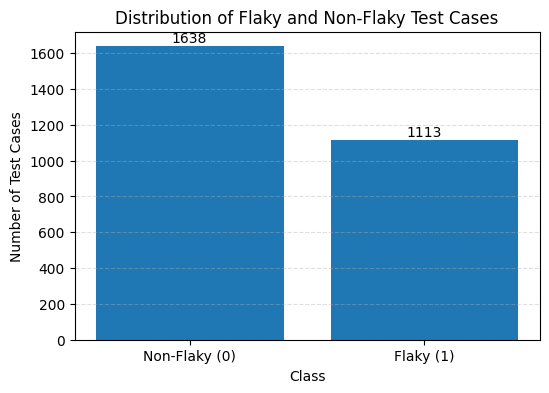

In [159]:
# ============================================================
# Class Distribution
# ============================================================

plt.figure(figsize=(6,4))

bars = plt.bar(
    label_df["Class"],
    label_df["Count"]
)

plt.title("Distribution of Flaky and Non-Flaky Test Cases")
plt.xlabel("Class")
plt.ylabel("Number of Test Cases")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Display values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.show()

In [160]:
# ============================================================
# Integrity Summary
# ============================================================

print("\n" + "=" * 80)
print("DATA INTEGRITY SUMMARY")
print("=" * 80)

if missing.values.sum() == 0:
    print("✓ No missing values detected.")
else:
    print("✗ Missing values detected.")

if duplicate_test_ids == 0:
    print("✓ No duplicate test identifiers detected.")
else:
    print(f"✗ {duplicate_test_ids} duplicate test identifiers detected.")

print(f"✓ Non-Flaky Tests : {label_counts[0]} ({label_df.iloc[0]['Percentage (%)']}%)")
print(f"✓ Flaky Tests     : {label_counts[1]} ({label_df.iloc[1]['Percentage (%)']}%)")

print("\n✓ Dataset integrity validation completed successfully.")


DATA INTEGRITY SUMMARY
✓ No missing values detected.
✓ No duplicate test identifiers detected.
✓ Non-Flaky Tests : 1638 (59.54%)
✓ Flaky Tests     : 1113 (40.46%)

✓ Dataset integrity validation completed successfully.


### 1.3 Context Completeness Analysis
This step evaluates the availability of contextual information associated with each test case. Unlike missing value analysis, which identifies incomplete or corrupted records, context completeness analysis determines whether each contextual artifact is available for use during prompt construction.

The dataset contains several context sources, including test code, helper methods, failure logs, and production code. Some context sources may legitimately be absent (e.g., a test may not define any helper methods). Such cases are considered valid observations rather than missing data.

The following context sources are evaluated:
- Test Code
- Helper Methods
- Failure Logs
- Code Under Test

### Justification
The objective of this research is to investigate the impact of context augmentation on flaky test classification. Therefore, it is important to quantify the availability of each context source before preprocessing.

Understanding the completeness of contextual artifacts helps:
- Characterize the dataset.
- Explain variations in prompt construction.
- Justify subsequent preprocessing decisions.
- Identify potential limitations of context-augmented prompting.

In [161]:
# ============================================================
# Step 1.3 - Context Completeness Analysis
# ============================================================

print("=" * 80)
print("CONTEXT COMPLETENESS ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def is_empty_text(value):
    if pd.isna(value):
        return True
    return str(value).strip() == ""

def is_empty_json(value):
    if value is None:
        return True
    if isinstance(value, dict):
        return len(value) == 0
    return False

# ------------------------------------------------------------
# Context Availability
# ------------------------------------------------------------

total_records = len(working_df)

context_summary = []

context_columns = {
    "Test Code": (
        working_df["test_code"],
        is_empty_text
    ),
    "Helper Methods": (
        working_df["helper_methods_json"],
        is_empty_json
    ),
    "Failure Log": (
        working_df["failure_log"],
        is_empty_text
    ),
    "Code Under Test": (
        working_df["code_under_test_json"],
        is_empty_json
    )
}

for context_name, (series, empty_checker) in context_columns.items():

    empty_count = series.apply(empty_checker).sum()

    available_count = total_records - empty_count

    context_summary.append({
        "Context Source": context_name,
        "Available": available_count,
        "Empty": empty_count,
        "Availability (%)": round(
            available_count / total_records * 100,
            2
        )
    })

context_df = pd.DataFrame(context_summary)

display(context_df)

CONTEXT COMPLETENESS ANALYSIS


,Context Source,Available,Empty,Availability (%)
0,Test Code,2745,6,99.78
1,Helper Methods,1411,1340,51.29
2,Failure Log,2689,62,97.75
3,Code Under Test,2746,5,99.82


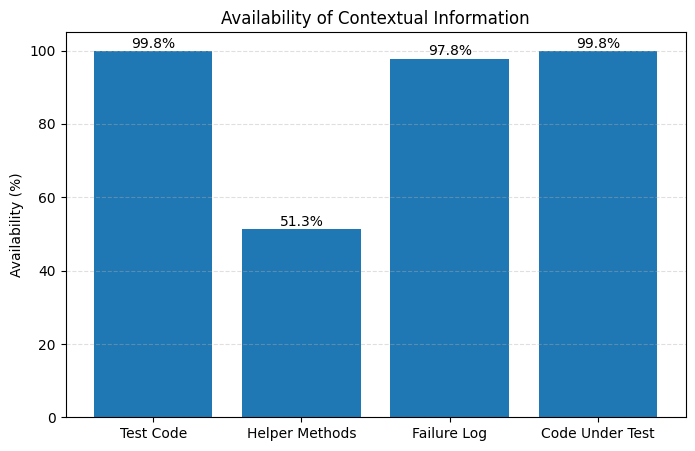

In [162]:
# ============================================================
# Context Availability
# ============================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    context_df["Context Source"],
    context_df["Availability (%)"]
)

plt.ylim(0,105)

plt.ylabel("Availability (%)")

plt.title("Availability of Contextual Information")

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+1,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()

### Investigation of Empty Contexts

Before interpreting the context completeness statistics, the records classified as containing empty contextual information are manually inspected.

This verification ensures that the completeness analysis correctly distinguishes between genuinely unavailable context and artifacts introduced by the extraction process or data formatting.

In [163]:
# ------------------------------------------------------------
# Investigate Empty Test Code
# ------------------------------------------------------------

empty_test = working_df[
    working_df["test_code"].apply(is_empty_text)
]

print("Empty Test Code Records:", len(empty_test))

display(
    empty_test[
        ["id","test_id","test_code"]
    ].head(10)
)

Empty Test Code Records: 6


,id,test_id,test_code
619,620,underscorejava63890cereplace,
913,914,wildflynaming3a83b7b18,
958,959,quickcheckc1c34,
1004,1005,quickcheck4858,
1010,1011,quickcheck4864,
1011,1012,quickcheck4865,


In [164]:
# ------------------------------------------------------------
# Investigate Empty Failure Logs
# ------------------------------------------------------------

empty_logs = working_df[
    working_df["failure_log"].apply(is_empty_text)
]

print("Empty Failure Logs:", len(empty_logs))

display(
    empty_logs[
        ["id","test_id","failure_log"]
    ].head(10)
)

Empty Failure Logs: 62


,id,test_id,failure_log
46,47,cloudstackpluginsnetworkelementsniciranvp2bb182ctestExecuteLiveLockWhenControllerAllowsLoginAndFollowsWithUnauthoriz...,
197,198,servicecombjavachassiscommoncommonrest94a672fshould_convert_exception_to_response_when_decode_request_failed,
253,254,mercurysystemplatformcoree659cafjournalYamlTest,
324,325,hippo4jinfracommonee2a81fbuildUrl,
362,363,javacpp2fd35c6testBufferCallback,
363,364,javacpp2fd35c6testEnum,
364,365,javacpp2fd35c6testFunctionPointer,
383,384,incubatorshardingsphereshardingorchestrationshardingorchestrationcorefcd7940assertPersistConfigurationForMasterSlave...,
384,385,incubatorshardingsphereshardingorchestrationshardingorchestrationcorefcd7940assertPersistConfigurationForShardingRul...,
447,448,flowableenginemodulesflowablecmmnengineconfigurator7cf1557testExitAvailableProcessTaskThroughExitSentryOnStage,


In [165]:
# ------------------------------------------------------------
# Investigate Empty Production Code
# ------------------------------------------------------------

empty_cut = working_df[
    working_df["code_under_test_json"].apply(is_empty_json)
]

print("Empty Code Under Test:", len(empty_cut))

display(
    empty_cut[
        [
            "id",
            "test_id",
            "code_under_test_json"
        ]
    ].head(10)
)

Empty Code Under Test: 5


,id,test_id,code_under_test_json
366,367,immutablesvaluefixtureb21e6bbroundtrip353,{}
367,368,immutablesvaluefixtureb21e6bbanyGetterSetter,{}
368,369,immutablesvaluefixtureb21e6bbjacksonMetaAnnotated,{}
369,370,immutablesvaluefixtureb21e6bbkeywordNames,{}
370,371,immutablesvaluefixtureb21e6bbmodifiableImmutableCollections,{}


### Interpretation

The context completeness analysis shows that the primary software artifact, **test code**, is available for nearly all test cases (99.78%), while helper methods are present in approximately half of the dataset. This is expected because many test classes do not define custom helper methods.

Failure logs and code under test are available for more than 97% of the dataset, indicating that the majority of test cases include rich contextual information for context-augmented prompting.

A small number of records lack test code or production code. These records will be reviewed during preprocessing to determine whether they represent valid edge cases or extraction failures.

## 1.4 Dataset Characterization
This step quantitatively characterizes the software artifacts contained in the dataset before preprocessing. The objective is to understand the size and distribution of each contextual information source used for Large Language Model (LLM) prompt construction.

The following context sources are analyzed:
- Test Code
- Helper Methods
- Failure Logs
- Code Under Test

For each context source, descriptive statistics are computed to measure its size and variability across the dataset.

### Justification

Large Language Models have limited context windows, making the size of input artifacts an important consideration. Characterizing the dataset before preprocessing provides quantitative evidence for subsequent preprocessing decisions and helps identify which contextual artifacts contribute most to the overall prompt length.

The reported statistics also serve as a baseline for evaluating the effectiveness of later preprocessing stages.

In [166]:
# ============================================================
# Step 1.4 - Dataset Characterization
# ============================================================

print("=" * 80)
print("DATASET CHARACTERIZATION")
print("=" * 80)

import json

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def text_length(value):
    if pd.isna(value):
        return 0
    return len(str(value))

def json_length(value):
    if value is None:
        return 0
    return len(json.dumps(value, ensure_ascii=False))

# ------------------------------------------------------------
# Calculate Artifact Sizes
# ------------------------------------------------------------

artifact_lengths = {
    "Test Code": working_df["test_code"].apply(text_length),
    "Helper Methods": working_df["helper_methods_json"].apply(json_length),
    "Failure Log": working_df["failure_log"].apply(text_length),
    "Code Under Test": working_df["code_under_test_json"].apply(json_length)
}

summary = []

for name, values in artifact_lengths.items():

    summary.append({

        "Context Source": name,

        "Minimum": int(values.min()),

        "25th Percentile": int(values.quantile(0.25)),

        "Median": int(values.median()),

        "Mean": round(values.mean(),2),

        "75th Percentile": int(values.quantile(0.75)),

        "95th Percentile": int(values.quantile(0.95)),

        "Maximum": int(values.max()),

        "Std Dev": round(values.std(),2)

    })

characterization_df = pd.DataFrame(summary)

display(characterization_df)

DATASET CHARACTERIZATION


,Context Source,Minimum,25th Percentile,Median,Mean,75th Percentile,95th Percentile,Maximum,Std Dev
0,Test Code,0,311,483,752.81,901,2082,21275,955.68
1,Helper Methods,2,2,81,362.43,307,1735,15441,863.49
2,Failure Log,0,1643,2952,3242.04,3415,6259,165927,6205.60
3,Code Under Test,2,1489,4474,27666.24,25689,109348,1572407,72062.04


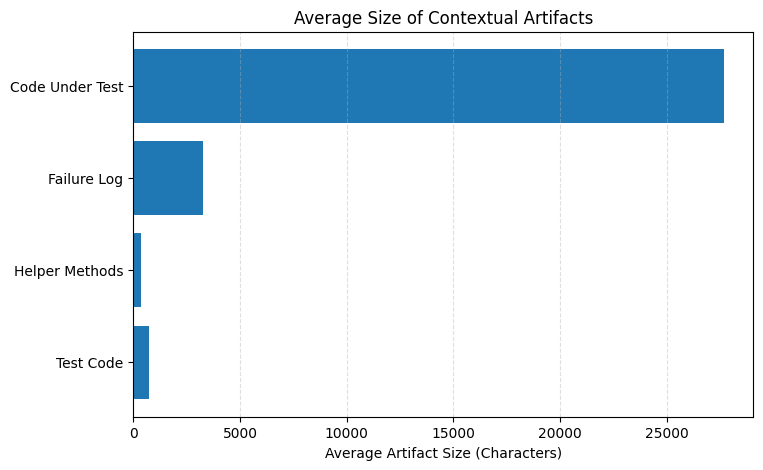

In [167]:
# ============================================================
# Average Context Size
# ============================================================

plt.figure(figsize=(8,5))

plt.barh(
    characterization_df["Context Source"],
    characterization_df["Mean"]
)

plt.xlabel("Average Artifact Size (Characters)")
plt.title("Average Size of Contextual Artifacts")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

In [168]:
print("\n" + "=" * 80)
print("DATASET CHARACTERIZATION SUMMARY")
print("=" * 80)

largest = characterization_df.loc[
    characterization_df["Mean"].idxmax()
]

print(f"Largest Context Source : {largest['Context Source']}")
print(f"Average Size           : {largest['Mean']:,.2f} characters")

print("\nObservation")

print(
    "Production code contributes the largest proportion of "
    "context provided to Large Language Models."
)

print(
    "This indicates that Code Under Test is the primary "
    "candidate for preprocessing to reduce prompt size."
)

print("\n✓ Dataset characterization completed successfully.")


DATASET CHARACTERIZATION SUMMARY
Largest Context Source : Code Under Test
Average Size           : 27,666.24 characters

Observation
Production code contributes the largest proportion of context provided to Large Language Models.
This indicates that Code Under Test is the primary candidate for preprocessing to reduce prompt size.

✓ Dataset characterization completed successfully.


### Interpretation

The dataset characterization demonstrates considerable variation in the size of the contextual software artifacts.

Among all context sources, **Code Under Test** is the dominant contributor to prompt length, with an average size of approximately **27,666 characters**, which is substantially larger than the remaining context sources.

The large difference between the median (4,474 characters) and the mean (27,666 characters), together with the maximum artifact size exceeding 1.5 million characters, indicates a highly right-skewed distribution. This suggests that only a small number of production classes contribute extremely large contexts.

Failure logs represent the second largest contextual artifact, whereas helper methods are generally small and contribute minimally to the overall prompt length.

These findings provide quantitative evidence that production code will have the greatest impact on LLM context window utilization and therefore requires the most attention during preprocessing and prompt construction.

## Step 2 - Dataset Refinement

### 2.1 Removal of Records Without Test Code
This step removes dataset records that cannot be used in the downstream Large Language Model (LLM) classification experiments.

The primary software artifact required for both code-only and context-augmented prompt construction is the test source code. Records without test code cannot be transformed into valid prompts and therefore cannot participate in the experimental evaluation.

### Justification

The objective of this research is to classify flaky tests using prompts constructed from software artifacts.

Both experimental configurations require the presence of test code:

- Code-only prompting
- Context-augmented prompting

In [169]:
# ============================================================
# Step 2.1 - Remove Records Without Test Code
# ============================================================

print("=" * 80)
print("REMOVE RECORDS WITHOUT TEST CODE")
print("=" * 80)

rows_before = len(working_df)

# Identify invalid records
invalid_test_code = working_df[
    working_df["test_code"].str.strip() == ""
]

print(f"Records identified for removal : {len(invalid_test_code)}")

if len(invalid_test_code) > 0:
    print("\nRemoved Test IDs")

    display(
        invalid_test_code[
            ["id", "test_id"]
        ]
    )

# Remove invalid records
working_df = working_df[
    working_df["test_code"].str.strip() != ""
].copy()

rows_after = len(working_df)

print("\nRows Before :", rows_before)
print("Rows After  :", rows_after)
print("Rows Removed:", rows_before - rows_after)

REMOVE RECORDS WITHOUT TEST CODE
Records identified for removal : 6

Removed Test IDs


,id,test_id
619,620,underscorejava63890cereplace
913,914,wildflynaming3a83b7b18
958,959,quickcheckc1c34
1004,1005,quickcheck4858
1010,1011,quickcheck4864
1011,1012,quickcheck4865



Rows Before : 2751
Rows After  : 2745
Rows Removed: 6


In [170]:
# ============================================================
# Validation
# ============================================================

print("=" * 80)
print("VALIDATION")
print("=" * 80)

remaining_empty = (
    working_df["test_code"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"Remaining Empty Test Code Records : {remaining_empty}")

assert remaining_empty == 0

print("\n✓ Validation Passed")

print("Every remaining record contains test code.")

VALIDATION
Remaining Empty Test Code Records : 0

✓ Validation Passed
Every remaining record contains test code.


In [171]:
print("=" * 80)
print("DATASET REFINEMENT SUMMARY")
print("=" * 80)

print(f"Original Dataset Size : {rows_before}")
print(f"Refined Dataset Size  : {rows_after}")

print(
    f"Records Removed       : {rows_before-rows_after} "
    f"({((rows_before-rows_after)/rows_before)*100:.2f}%)"
)

print("\n✓ Dataset refinement completed successfully.")

DATASET REFINEMENT SUMMARY
Original Dataset Size : 2751
Refined Dataset Size  : 2745
Records Removed       : 6 (0.22%)

✓ Dataset refinement completed successfully.


## Step 3 - Test Code Preprocessing

This step preprocesses the Java test source code to remove lexical elements that do not contribute to program execution while preserving the semantic behavior of the test.

The preprocessing focuses on reducing unnecessary prompt tokens before supplying the test code to Large Language Models (LLMs).

### Justification

Java source files frequently contain documentation comments, inline comments, excessive blank lines, and inconsistent whitespace. Although these elements improve human readability, they do not influence program execution or the semantics of the test case.

Removing these lexical artifacts reduces prompt length without modifying the executable behavior of the test.

The preprocessing therefore improves prompt efficiency while preserving the software engineering information required for flaky test classification.

### Preprocessing Operations

The following transformations are applied:

- Remove Javadoc comments (`/** ... */`)
- Remove block comments (`/* ... */`)
- Remove single-line comments (`// ...`)
- Remove trailing whitespace
- Collapse multiple blank lines into a single blank line
- Standardize line endings

No executable Java statements are modified during preprocessing.

In [172]:
# ============================================================
# Step 3.1 - Test Code Preprocessing Function
# ============================================================

import re
import pandas as pd

def remove_java_comments(code):
    """
    Removes Java comments while preserving string and character literals.
    """

    if pd.isna(code):
        return ""

    code = str(code)

    result = []

    i = 0
    n = len(code)

    in_string = False
    in_char = False
    in_line_comment = False
    in_block_comment = False
    escape = False

    while i < n:

        c = code[i]
        nxt = code[i + 1] if i + 1 < n else ""

        # ----------------------------------------------------
        # Inside line comment
        # ----------------------------------------------------
        if in_line_comment:

            if c == "\n":
                in_line_comment = False
                result.append(c)

            i += 1
            continue

        # ----------------------------------------------------
        # Inside block comment
        # ----------------------------------------------------
        if in_block_comment:

            if c == "*" and nxt == "/":
                in_block_comment = False
                i += 2
                continue

            i += 1
            continue

        # ----------------------------------------------------
        # Inside string literal
        # ----------------------------------------------------
        if in_string:

            result.append(c)

            if escape:
                escape = False

            elif c == "\\":
                escape = True

            elif c == '"':
                in_string = False

            i += 1
            continue

        # ----------------------------------------------------
        # Inside character literal
        # ----------------------------------------------------
        if in_char:

            result.append(c)

            if escape:
                escape = False

            elif c == "\\":
                escape = True

            elif c == "'":
                in_char = False

            i += 1
            continue

        # ----------------------------------------------------
        # Detect start of comments
        # ----------------------------------------------------
        if c == "/" and nxt == "/":
            in_line_comment = True
            i += 2
            continue

        if c == "/" and nxt == "*":
            in_block_comment = True
            i += 2
            continue

        # ----------------------------------------------------
        # Detect string literals
        # ----------------------------------------------------
        if c == '"':
            in_string = True
            result.append(c)
            i += 1
            continue

        # ----------------------------------------------------
        # Detect character literals
        # ----------------------------------------------------
        if c == "'":
            in_char = True
            result.append(c)
            i += 1
            continue

        result.append(c)

        i += 1

    cleaned = "".join(result)

    # --------------------------------------------------------
    # Normalize line endings
    # --------------------------------------------------------

    cleaned = cleaned.replace("\r\n", "\n").replace("\r", "\n")

    # --------------------------------------------------------
    # Remove trailing whitespace
    # --------------------------------------------------------

    cleaned = "\n".join(
        line.rstrip()
        for line in cleaned.splitlines()
    )

    # --------------------------------------------------------
    # Collapse multiple blank lines
    # --------------------------------------------------------

    cleaned = re.sub(
        r"\n\s*\n+",
        "\n\n",
        cleaned
    )

    return cleaned.strip()


# Alias used throughout the notebook
clean_java_code = remove_java_comments

I would replace the regex-based cleaner with a state-machine (lexical scanner). It is still pure Python, requires no external libraries, and is much safer because it preserves Java string literals while removing only actual comments.

### 3.2 Validate Test Code Preprocessing Function

In [173]:
sample = '''
@Test
public void test(){

    String url = "https://github.com/openai/project";

    // remove this comment

    assertNotNull(url);
}
'''

print("========== BEFORE ==========")
print(sample)

print("\n========== AFTER ==========")
print(clean_java_code(sample))

========== BEFORE ==========

@Test
public void test(){

    String url = "https://github.com/openai/project";

    // remove this comment

    assertNotNull(url);
}


========== AFTER ==========
@Test
public void test(){

    String url = "https://github.com/openai/project";

    assertNotNull(url);
}


### Validation - Character Literal Preservation

In [174]:
sample = r"""
@Test
public void test(){

    char slash='/';

    String regex="//abc";

    // remove

    assertEquals('/', slash);

}
"""

print(clean_java_code(sample))

@Test
public void test(){

    char slash='/';

    String regex="//abc";

    assertEquals('/', slash);

}


### 3.3 Apply Test Code Preprocessing

This step applies the validated Java test code preprocessing function to every test case in the refined dataset.

To support validation and quantitative evaluation, the original test code is preserved temporarily before preprocessing.

### Justification
Keeping both the original and preprocessed versions enables quantitative evaluation of preprocessing effectiveness, including artifact size reduction and before–after comparisons. This temporary preservation also provides traceability during preprocessing validation.

The original version will be removed before exporting the final preprocessed dataset.

In [175]:
# ============================================================
# Step 3.3 - Apply Test Code Preprocessing
# ============================================================

print("=" * 80)
print("APPLY TEST CODE PREPROCESSING")
print("=" * 80)

# ------------------------------------------------------------
# Preserve original version
# ------------------------------------------------------------

working_df["test_code_original"] = working_df["test_code"]

# ------------------------------------------------------------
# Apply preprocessing
# ------------------------------------------------------------

working_df["test_code"] = working_df["test_code"].apply(clean_java_code)

print(f"Processed Records : {len(working_df)}")

print("\n✓ Test code preprocessing completed successfully.")

APPLY TEST CODE PREPROCESSING
Processed Records : 2745

✓ Test code preprocessing completed successfully.


### 3.4 Validate Test Code Preprocessing
This step validates that preprocessing has been successfully applied to every test case while preserving the integrity of the dataset.

The validation confirms:
- Dataset size remains unchanged.
- Every test case still contains executable test code.
- Original test code has been preserved for comparison.

In [176]:
# ============================================================
# Step 3.4 - Validation
# ============================================================

print("=" * 80)
print("VALIDATE TEST CODE PREPROCESSING")
print("=" * 80)

# Dataset size
print(f"Dataset Size : {len(working_df)}")

# Empty test code
empty_test_code = (
    working_df["test_code"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"Empty Test Code Records : {empty_test_code}")

# Original column exists
print(f"Original Column Preserved : {'test_code_original' in working_df.columns}")

assert empty_test_code == 0

print("\n✓ Validation passed.")

VALIDATE TEST CODE PREPROCESSING
Dataset Size : 2745
Empty Test Code Records : 0
Original Column Preserved : True

✓ Validation passed.


### 3.5 Quantify Preprocessing Effectiveness
This step measures the impact of preprocessing on the size of the test code artifacts.

The reduction in artifact size provides quantitative evidence that lexical preprocessing decreases prompt length while preserving executable semantics.

In [177]:
# ============================================================
# Step 3.5 - Quantify Reduction
# ============================================================

print("=" * 80)
print("PREPROCESSING EFFECTIVENESS")
print("=" * 80)

before = working_df["test_code_original"].str.len()

after = working_df["test_code"].str.len()

reduction = before - after

summary = pd.DataFrame({

    "Metric":[
        "Average Size Before",
        "Average Size After",
        "Average Reduction",
        "Reduction Percentage"
    ],

    "Value":[
        round(before.mean(),2),
        round(after.mean(),2),
        round(reduction.mean(),2),
        round((reduction.sum()/before.sum())*100,2)
    ]

})

display(summary)

PREPROCESSING EFFECTIVENESS


,Metric,Value
0,Average Size Before,754.45
1,Average Size After,710.87
2,Average Reduction,43.58
3,Reduction Percentage,5.78


In [178]:
# ============================================================
# Additional Effectiveness Metrics
# ============================================================

modified = (
    working_df["test_code_original"] != working_df["test_code"]
).sum()

print(f"Modified Test Cases : {modified}")
print(f"Unchanged Test Cases: {len(working_df) - modified}")

print(
    f"Modification Rate   : "
    f"{modified/len(working_df)*100:.2f}%"
)

Modified Test Cases : 977
Unchanged Test Cases: 1768
Modification Rate   : 35.59%


### Interpretation

The preprocessing reduced the average size of Java test code from **754.45** to **710.87** characters, corresponding to an overall reduction of **5.78%**.

A total of **977** test cases (**35.59%** of the refined dataset) were modified during preprocessing. The remaining **1,768** test cases were already free of removable lexical artifacts and therefore remained unchanged.

The reduction was achieved by removing non-executable lexical elements, including Javadoc comments, block comments, inline comments, and redundant whitespace, while preserving executable Java semantics.

The relatively modest reduction in artifact size indicates that the preprocessing is conservative and semantics-preserving. Rather than simplifying the program logic, it selectively removes documentation and formatting artifacts to improve prompt efficiency for downstream LLM-based flaky test classification.

In [179]:
# ============================================================
# Step 3.6 - Before vs After Comparison
# ============================================================

from IPython.display import display, Markdown
import pandas as pd

print("=" * 80)
print("BEFORE VS AFTER COMPARISON")
print("=" * 80)

# ------------------------------------------------------------------
# Select modified examples
# ------------------------------------------------------------------

modified_df = working_df[
    working_df["test_code_original"] != working_df["test_code"]
].copy()

sample_examples = modified_df.sample(
    n=min(3, len(modified_df)),
    random_state=42
)

print(f"Modified Test Cases : {len(modified_df)}")
print(f"Displaying          : {len(sample_examples)} representative examples\n")

# ------------------------------------------------------------------
# Display examples
# ------------------------------------------------------------------

for idx, (_, row) in enumerate(sample_examples.iterrows(), start=1):

    before = row["test_code_original"]
    after = row["test_code"]

    before_size = len(before)
    after_size = len(after)

    removed = before_size - after_size
    reduction = (removed / before_size) * 100 if before_size else 0

    display(Markdown(f"# Example {idx}"))

    summary = pd.DataFrame({
        "Property": [
            "Test ID",
            "Original Size (Characters)",
            "Processed Size (Characters)",
            "Characters Removed",
            "Reduction (%)"
        ],
        "Value": [
            row["test_id"],
            before_size,
            after_size,
            removed,
            f"{reduction:.2f}%"
        ]
    })

    display(summary)

    display(Markdown("### Original Test Code"))

    display(
        Markdown(
            f"```java\n{before}\n```"
        )
    )

    display(Markdown("### Preprocessed Test Code"))

    display(
        Markdown(
            f"```java\n{after}\n```"
        )
    )

    display(Markdown("---"))

BEFORE VS AFTER COMPARISON
Modified Test Cases : 977
Displaying          : 3 representative examples



# Example 1

,Property,Value
0,Test ID,shenyushenyuadmin02696b4testBuildHandle5
1,Original Size (Characters),5386
2,Processed Size (Characters),5370
3,Characters Removed,16
4,Reduction (%),0.30%


### Original Test Code

```java
@Test
    public void testBuildHandle() {
        shenyuClientRegisterSpringCloudService = spy(shenyuClientRegisterSpringCloudService);
        
        final String returnStr = "{serviceId:'test1',gray:false,divideUpstreams:["
                + "{weight:50,warmup:10,protocol:'http://',upstreamHost:'localhost',upstreamUrl:'localhost:8090',status:'true',timestamp:1637909490935},"
                + "{weight:50,warmup:10,protocol:'http://',upstreamHost:'localhost',upstreamUrl:'localhost:8091',status:'true',timestamp:1637909490935}]}";
        final String expected = "{\"serviceId\":\"test1\",\"gray\":false,\"divideUpstreams\":["
                + "{\"weight\":50,\"warmup\":10,\"protocol\":\"http://\",\"upstreamHost\":\"localhost\",\"upstreamUrl\":\"localhost:8090\",\"status\":true,\"timestamp\":1637909490935},"
                + "{\"weight\":50,\"warmup\":10,\"protocol\":\"http://\",\"upstreamHost\":\"localhost\",\"upstreamUrl\":\"localhost:8091\",\"status\":false,\"timestamp\":1637909490935}]}";
        final URIRegisterDTO dto1 = URIRegisterDTO.builder().appName("test2").rpcType(RpcTypeEnum.SPRING_CLOUD.getName()).host(HOST).port(8090).build();
        final URIRegisterDTO dto2 = URIRegisterDTO.builder().appName("test2").rpcType(RpcTypeEnum.SPRING_CLOUD.getName()).host(HOST).port(8091).build();
        
        List<URIRegisterDTO> list = new ArrayList<>();
        list.add(dto1);
        SelectorDO selectorDO = mock(SelectorDO.class);
        doReturn(false).when(shenyuClientRegisterSpringCloudService).doSubmit(any(), any());
        when(selectorDO.getHandle()).thenReturn(returnStr);
        String actual = shenyuClientRegisterSpringCloudService.buildHandle(list, selectorDO);
        assertEquals(expected.replaceAll("\\d{13}", "0"), actual.replaceAll("\\d{13}", "0"));
        SpringCloudSelectorHandle handle = GsonUtils.getInstance().fromJson(actual, SpringCloudSelectorHandle.class);
        assertEquals(handle.getDivideUpstreams().size(), 2);
        assertEquals(handle.getDivideUpstreams().stream().filter(r -> list.stream().map(dto -> CommonUpstreamUtils.buildUrl(dto.getHost(), dto.getPort()))
                .anyMatch(url -> url.equals(r.getUpstreamUrl()))).allMatch(r -> r.isStatus()), true);
        assertEquals(handle.getDivideUpstreams().stream().filter(r -> list.stream().map(dto -> CommonUpstreamUtils.buildUrl(dto.getHost(), dto.getPort()))
                .noneMatch(url -> url.equals(r.getUpstreamUrl()))).allMatch(r -> !r.isStatus()), true);

        list.clear();
        list.add(dto1);
        list.add(dto2);
        selectorDO = mock(SelectorDO.class);
        doReturn(false).when(shenyuClientRegisterSpringCloudService).doSubmit(any(), any());
        when(selectorDO.getHandle()).thenReturn(returnStr);
        actual = shenyuClientRegisterSpringCloudService.buildHandle(list, selectorDO);
        handle = GsonUtils.getInstance().fromJson(actual, SpringCloudSelectorHandle.class);
        assertEquals(handle.getDivideUpstreams().size(), 2);
        assertEquals(handle.getDivideUpstreams().stream().filter(r -> list.stream().map(dto -> CommonUpstreamUtils.buildUrl(dto.getHost(), dto.getPort()))
                .anyMatch(url -> url.equals(r.getUpstreamUrl()))).allMatch(r -> r.isStatus()), true);
        assertEquals(handle.getDivideUpstreams().stream().filter(r -> list.stream().map(dto -> CommonUpstreamUtils.buildUrl(dto.getHost(), dto.getPort()))
                .noneMatch(url -> url.equals(r.getUpstreamUrl()))).allMatch(r -> !r.isStatus()), true);

        list.clear();
        list.add(dto1);
        selectorDO = mock(SelectorDO.class);
        doReturn(false).when(shenyuClientRegisterSpringCloudService).doSubmit(any(), any());
        when(selectorDO.getHandle()).thenReturn("{serviceId:'test1',gray:false,divideUpstreams:[]}");
        actual = shenyuClientRegisterSpringCloudService.buildHandle(list, selectorDO);
        handle = GsonUtils.getInstance().fromJson(actual, SpringCloudSelectorHandle.class);
        assertEquals(handle.getDivideUpstreams().size(), 1);
        assertEquals(handle.getDivideUpstreams().stream().anyMatch(r -> r.isStatus() && r.getUpstreamUrl().equals(CommonUpstreamUtils.buildUrl(dto1.getHost(), dto1.getPort()))), true);

        list.clear();
        dto1.setEventType(EventType.DELETED);
        list.add(dto1);
        selectorDO = mock(SelectorDO.class);
        doReturn(false).when(shenyuClientRegisterSpringCloudService).doSubmit(any(), any());
        when(selectorDO.getHandle()).thenReturn("{serviceId:'test1',gray:false,divideUpstreams:[]}");
        actual = shenyuClientRegisterSpringCloudService.buildHandle(list, selectorDO);
        handle = GsonUtils.getInstance().fromJson(actual, SpringCloudSelectorHandle.class);
        assertEquals(handle.getDivideUpstreams().size(), 1);
        assertEquals(handle.getDivideUpstreams().stream().anyMatch(r -> !r.isStatus() && r.getUpstreamUrl().equals(CommonUpstreamUtils.buildUrl(dto1.getHost(), dto1.getPort()))), true);

        list.clear();
        doReturn(false).when(shenyuClientRegisterSpringCloudService).doSubmit(any(), any());
        actual = shenyuClientRegisterSpringCloudService.buildHandle(list, selectorDO);
        handle = GsonUtils.getInstance().fromJson(actual, SpringCloudSelectorHandle.class);
        assertEquals(handle.getDivideUpstreams().stream().allMatch(r -> !r.isStatus()), true);
    }
```

...

### Original Test Code

```java
public void testObjectToXml() throws Exception {
        // given
        SimpleBean obj = new SimpleBean();
        obj.setName("Jan");
        obj.setAge(12L);
        obj.setParents(Arrays.asList("Adam", "Ewa"));

        // when
        Writer stream = new StringWriter();
        handler.fromObject(ai, obj, null, stream);

        // then
        stream.flush();
        assertEquals(xml, stream.toString());
    }
```

### Preprocessed Test Code

```java
public void testObjectToXml() throws Exception {

        SimpleBean obj = new SimpleBean();
        obj.setName("Jan");
        obj.setAge(12L);
        obj.setParents(Arrays.asList("Adam", "Ewa"));

        Writer stream = new StringWriter();
        handler.fromObject(ai, obj, null, stream);

        stream.flush();
        assertEquals(xml, stream.toString());
    }
```

---

## Step 4 - Helper Methods Preprocessing

This step preprocesses the helper methods associated with each test case.

Unlike production code, helper methods are preserved in their entirety because they frequently contain setup logic, custom assertions, synchronization utilities, waiting mechanisms, and mock initialization that may directly contribute to flaky behavior.

The preprocessing removes only non-executable lexical artifacts while preserving the complete implementation of each helper method.

### Justification

Helper methods exhibit strong semantic coupling with their corresponding test cases. Removing or summarizing helper method bodies may eliminate contextual information required for identifying the root causes of flaky behavior.

Therefore, this preprocessing applies the same validated lexical cleaning function developed for Java test code while preserving every helper method in full.


HELPER METHODS ANALYSIS
Total Test Cases        : 2745
With Helper Methods     : 1411 (51.40%)
Without Helper Methods  : 1334 (48.60%)


,Metric,Value
0,Tests with Helper Methods,1411.00
1,Tests without Helper Methods,1334.00
2,Average Helper Methods per Test,0.86
3,Average Helper Methods (Available Tests),1.67
4,Maximum Helper Methods,20.00


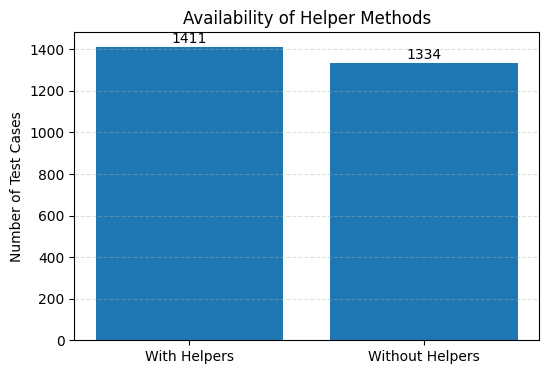

In [180]:
# ============================================================
# Step 4.1 - Analyse Helper Methods
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("HELPER METHODS ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Helper Method Availability
# ------------------------------------------------------------

has_helpers = working_df["helper_methods_json"].apply(
    lambda x: isinstance(x, dict) and len(x) > 0
)

total = len(working_df)
available = has_helpers.sum()
empty = total - available

print(f"Total Test Cases        : {total}")
print(f"With Helper Methods     : {available} ({available/total*100:.2f}%)")
print(f"Without Helper Methods  : {empty} ({empty/total*100:.2f}%)")

# ------------------------------------------------------------
# Helper Method Statistics
# ------------------------------------------------------------

method_counts = working_df["helper_methods_json"].apply(
    lambda x: len(x) if isinstance(x, dict) else 0
)

non_empty_counts = method_counts[method_counts > 0]

summary = pd.DataFrame({

    "Metric": [
        "Tests with Helper Methods",
        "Tests without Helper Methods",
        "Average Helper Methods per Test",
        "Average Helper Methods (Available Tests)",
        "Maximum Helper Methods"
    ],

    "Value": [
        available,
        empty,
        round(method_counts.mean(), 2),
        round(non_empty_counts.mean(), 2),
        int(method_counts.max())
    ]

})

display(summary)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["With Helpers", "Without Helpers"],
    [available, empty]
)

plt.ylabel("Number of Test Cases")
plt.title("Availability of Helper Methods")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Display values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center"
    )

plt.show()

### 4.2 Inspect Helper Methods Structure

Before preprocessing helper methods, inspect the internal structure of the
`helper_methods_json` column.

This validation ensures that preprocessing preserves the original JSON
structure while cleaning only the Java source code contained within each
helper method.

In [181]:
# ============================================================
# Step 4.2 - Inspect Helper Methods Structure
# ============================================================

import json
from pprint import pprint

sample = working_df[
    working_df["helper_methods_json"].apply(
        lambda x: isinstance(x, dict) and len(x) > 0
    )
].iloc[0]

print("=" * 80)
print("HELPER METHODS JSON STRUCTURE")
print("=" * 80)

print(f"Test ID : {sample['test_id']}\n")

print("Number of Helper Methods :",
      len(sample["helper_methods_json"]))

print("\nDictionary Keys")

for key in sample["helper_methods_json"].keys():
    print("-", key)

print("\nComplete JSON Structure\n")

pprint(sample["helper_methods_json"])

HELPER METHODS JSON STRUCTURE
Test ID : hadoophadoopmapreduceprojecthadoopmapreduceclienthadoopmapreduceclientcore5b215f2testHumanPrinterAll

Number of Helper Methods : 2

Dictionary Keys
- createJobInfo
- run

Complete JSON Structure

{'createJobInfo': 'private static JobHistoryParser.JobInfo createJobInfo() {\n'
                  '    JobHistoryParser.JobInfo job = new '
                  'JobHistoryParser.JobInfo();\n'
                  '    job.submitTime = 1317928501754L;\n'
                  '    job.finishTime = job.submitTime + 15000;\n'
                  '    job.jobid = JobID.forName("job_1317928501754_0001");\n'
                  '    job.username = "rkanter";\n'
                  '    job.jobname = "my job";\n'
                  '    job.jobQueueName = "my queue";\n'
                  '    job.jobConfPath = "/tmp/job.xml";\n'
                  '    job.launchTime = job.submitTime + 1000;\n'
                  '    job.totalMaps = 5;\n'
                  '    job.totalReduces

### 4.3 Apply Helper Method Preprocessing

This step applies the validated Java source code preprocessing function to every helper method contained within the `helper_methods_json` artifact.

Each helper method is preprocessed independently while preserving:

- the original JSON structure,
- helper method names (dictionary keys),
- complete helper method implementations.

### Justification

Helper methods often contain setup logic, synchronization utilities, waiting mechanisms, mock initialization, and reusable assertions that may influence flaky behaviour.

Therefore, preprocessing removes only non-executable lexical artifacts from each helper method while preserving its complete executable semantics.

In [182]:
# ============================================================
# Step 4.3 - Apply Helper Method Preprocessing
# ============================================================

print("=" * 80)
print("APPLY HELPER METHOD PREPROCESSING")
print("=" * 80)

# ------------------------------------------------------------
# Preserve original helper methods
# ------------------------------------------------------------

working_df["helper_methods_json_original"] = (
    working_df["helper_methods_json"]
)

# ------------------------------------------------------------
# Preprocess helper methods
# ------------------------------------------------------------

def preprocess_helper_methods(helper_dict):

    if not isinstance(helper_dict, dict):
        return helper_dict

    cleaned = {}

    for method_name, method_code in helper_dict.items():

        cleaned[method_name] = clean_java_code(method_code)

    return cleaned


working_df["helper_methods_json"] = (
    working_df["helper_methods_json"]
    .apply(preprocess_helper_methods)
)

print(f"Processed Records : {len(working_df)}")

print("\n✓ Helper method preprocessing completed successfully.")

APPLY HELPER METHOD PREPROCESSING
Processed Records : 2745

✓ Helper method preprocessing completed successfully.


### 4.4 Validate Helper Method Preprocessing
This step validates that helper method preprocessing preserved the original
dictionary structure while successfully cleaning the Java source code of each
helper method.

The validation confirms:
- Number of helper methods remains unchanged.
- Dictionary keys are preserved.
- Empty helper method dictionaries remain unchanged.
- No helper method becomes empty after preprocessing.

In [183]:
# ============================================================
# Step 4.4 - Validate Helper Method Preprocessing
# ============================================================

print("=" * 80)
print("VALIDATE HELPER METHOD PREPROCESSING")
print("=" * 80)

# ------------------------------------------------------------
# Validation 1
# Number of helper methods
# ------------------------------------------------------------

original_counts = working_df["helper_methods_json_original"].apply(
    lambda x: len(x) if isinstance(x, dict) else 0
)

processed_counts = working_df["helper_methods_json"].apply(
    lambda x: len(x) if isinstance(x, dict) else 0
)

same_count = (original_counts == processed_counts).all()

print(f"Helper Method Count Preserved : {same_count}")

# ------------------------------------------------------------
# Validation 2
# Dictionary keys
# ------------------------------------------------------------

keys_preserved = True

for original, processed in zip(
    working_df["helper_methods_json_original"],
    working_df["helper_methods_json"]
):

    if isinstance(original, dict) and isinstance(processed, dict):

        if set(original.keys()) != set(processed.keys()):
            keys_preserved = False
            break

print(f"Dictionary Keys Preserved     : {keys_preserved}")

# ------------------------------------------------------------
# Validation 3
# Empty methods
# ------------------------------------------------------------

empty_methods = 0

for helper_dict in working_df["helper_methods_json"]:

    if not isinstance(helper_dict, dict):
        continue

    for method_code in helper_dict.values():

        if method_code.strip() == "":
            empty_methods += 1

print(f"Empty Helper Methods          : {empty_methods}")

# ------------------------------------------------------------
# Validation Result
# ------------------------------------------------------------

assert same_count
assert keys_preserved
assert empty_methods == 0

print("\n✓ Validation passed successfully.")

VALIDATE HELPER METHOD PREPROCESSING
Helper Method Count Preserved : True
Dictionary Keys Preserved     : True
Empty Helper Methods          : 0

✓ Validation passed successfully.


### 4.5 Quantify Preprocessing Effectiveness
This step measures the impact of preprocessing on helper method artifacts.

For each test case, the total size of all helper method implementations is calculated before and after preprocessing. The comparison provides quantitative evidence that lexical preprocessing reduces prompt size while preserving executable helper method implementations.

In [184]:
# ============================================================
# Step 4.5 - Quantify Helper Method Reduction
# ============================================================

print("=" * 80)
print("HELPER METHOD PREPROCESSING EFFECTIVENESS")
print("=" * 80)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def helper_size(helper_dict):

    if not isinstance(helper_dict, dict):
        return 0

    return sum(len(code) for code in helper_dict.values())


before = working_df["helper_methods_json_original"].apply(helper_size)

after = working_df["helper_methods_json"].apply(helper_size)

reduction = before - after

modified = (
    working_df["helper_methods_json_original"] !=
    working_df["helper_methods_json"]
).sum()

summary = pd.DataFrame({

    "Metric":[
        "Mean Artifact Size Before",
        "Mean Artifact Size After",
        "Mean Size Reduction",
        "Overall Reduction (%)",
        "Modified Test Cases",
        "Modification Rate (%)"
    ],

    "Value":[
        round(before.mean(),2),
        round(after.mean(),2),
        round(reduction.mean(),2),
        round((reduction.sum()/before.sum())*100,2)
            if before.sum() > 0 else 0,
        modified,
        round(modified/len(working_df)*100,2)
    ]

})

display(summary)

HELPER METHOD PREPROCESSING EFFECTIVENESS


,Metric,Value
0,Mean Artifact Size Before,333.22
1,Mean Artifact Size After,281.21
2,Mean Size Reduction,52.01
3,Overall Reduction (%),15.61
4,Modified Test Cases,647.00
5,Modification Rate (%),23.57


### Interpretation

The preprocessing reduced the mean helper method artifact size from **333.22** to **281.21** characters, corresponding to an overall reduction of **15.61%**.

A total of **647** test cases (**23.57%** of the refined dataset) contained helper methods that were modified during preprocessing. The remaining helper method artifacts either contained no removable lexical elements or were empty.

The reduction was achieved by removing non-executable lexical artifacts, including comments and redundant whitespace, while preserving the complete implementation and executable semantics of every helper method.

These results demonstrate that helper methods contain substantially more removable lexical content than test methods, making preprocessing particularly beneficial for reducing LLM prompt size without sacrificing contextual information.

### 4.6 Before and After Comparison
This step presents representative examples illustrating the effect of helper method preprocessing.

Only helper method artifacts that changed during preprocessing are displayed. For each example, the original and preprocessed versions are compared together with artifact size statistics.

The objective is to qualitatively verify that preprocessing removes only non-executable lexical artifacts while preserving complete helper method implementations.

In [185]:
# ============================================================
# Step 4.6 - Before vs After Comparison
# ============================================================

from IPython.display import display, Markdown
import pandas as pd
import json

print("=" * 80)
print("HELPER METHODS BEFORE VS AFTER")
print("=" * 80)

# ------------------------------------------------------------
# Select modified helper method artifacts
# ------------------------------------------------------------

modified_df = working_df[
    working_df["helper_methods_json_original"] !=
    working_df["helper_methods_json"]
].copy()

sample_examples = modified_df.sample(
    n=min(3, len(modified_df)),
    random_state=42
)

print(f"Modified Test Cases : {len(modified_df)}")
print(f"Displaying          : {len(sample_examples)} representative examples\n")

# ------------------------------------------------------------
# Display examples
# ------------------------------------------------------------

for idx, (_, row) in enumerate(sample_examples.iterrows(), start=1):

    before = row["helper_methods_json_original"]
    after = row["helper_methods_json"]

    before_size = sum(len(v) for v in before.values())
    after_size = sum(len(v) for v in after.values())

    removed = before_size - after_size

    reduction = (
        removed / before_size * 100
        if before_size > 0 else 0
    )

    display(Markdown(f"# Example {idx}"))

    summary = pd.DataFrame({
        "Property": [
            "Test ID",
            "Number of Helper Methods",
            "Original Size (Characters)",
            "Processed Size (Characters)",
            "Characters Removed",
            "Reduction (%)"
        ],
        "Value": [
            row["test_id"],
            len(before),
            before_size,
            after_size,
            removed,
            f"{reduction:.2f}%"
        ]
    })

    display(summary)

    display(Markdown("### Original Helper Methods"))

    display(
        Markdown(
            f"```json\n{json.dumps(before, indent=4)}\n```"
        )
    )

    display(Markdown("### Preprocessed Helper Methods"))

    display(
        Markdown(
            f"```json\n{json.dumps(after, indent=4)}\n```"
        )
    )

    display(Markdown("---"))

HELPER METHODS BEFORE VS AFTER
Modified Test Cases : 647
Displaying          : 3 representative examples



# Example 1

,Property,Value
0,Test ID,Math-68-1
1,Number of Helper Methods,2
2,Original Size (Characters),1423
3,Processed Size (Characters),1348
4,Characters Removed,75
5,Reduction (%),5.27%


### Original Helper Methods

```json
{
    "JennrichSampsonFunction": "public JennrichSampsonFunction(int m, double[] startParams,\n                                   double theoreticalStartCost,\n                                   double theoreticalMinCost,\n                                   double[] theoreticalMinParams) {\n      super(m, startParams, theoreticalMinCost,\n            theoreticalMinParams);\n    }",
    "minpackTest": "private void minpackTest(MinpackFunction function, boolean exceptionExpected) {\n      LevenbergMarquardtOptimizer optimizer = new LevenbergMarquardtOptimizer();\n      optimizer.setMaxIterations(100 * (function.getN() + 1));\n      optimizer.setCostRelativeTolerance(Math.sqrt(2.22044604926e-16));\n      optimizer.setParRelativeTolerance(Math.sqrt(2.22044604926e-16));\n      optimizer.setOrthoTolerance(2.22044604926e-16);\n//      assertTrue(function.checkTheoreticalStartCost(optimizer.getRMS()));\n      try {\n          VectorialPointValuePair optimum =\n              optimizer.optimize(function,\n                                 function.getTarget(), function.getWeight(),\n                                 function.getStartPoint());\n          assertFalse(exceptionExpected);\n          function.checkTheoreticalMinCost(optimizer.getRMS());\n          function.checkTheoreticalMinParams(optimum);\n      } catch (OptimizationException lsse) {\n          assertTrue(exceptionExpected);\n      } catch (FunctionEvaluationException fe) {\n          assertTrue(exceptionExpected);\n      }\n  }"
}
```

...

### Original Helper Methods

```json
{
    "compileAndCheck": "private void compileAndCheck(String js, String expected) {\n    Result result = compileAndExportExterns(js);\n    \n    assertEquals(expected, result.externExport);\n  }"
}
```

### Preprocessed Helper Methods

```json
{
    "compileAndCheck": "private void compileAndCheck(String js, String expected) {\n    Result result = compileAndExportExterns(js);\n\n    assertEquals(expected, result.externExport);\n  }"
}
```

---

## Step 4 Summary

### Completed Operations

The following preprocessing operations were successfully applied to helper method artifacts:

- Preserved the original JSON structure.
- Preserved helper method names.
- Preserved complete helper method implementations.
- Removed Javadoc comments.
- Removed block comments.
- Removed single-line comments.
- Removed redundant blank lines.
- Removed trailing whitespace.

### Validation Summary

Validation confirmed that:

- The number of helper methods remained unchanged.
- Dictionary keys were preserved.
- No helper methods became empty after preprocessing.
- Executable Java semantics were preserved.

### Quantitative Evaluation

Helper method preprocessing reduced the mean artifact size from **333.22** to **281.21** characters, corresponding to an overall reduction of **15.61%**.

A total of **647** helper method artifacts (**23.57%** of the refined dataset) were modified through the removal of non-executable lexical artifacts.

The resulting helper method artifacts retain their complete implementations while providing a more compact representation for downstream LLM prompt construction.

## Step 5 - Failure Log Preprocessing
This step analyses the runtime failure logs associated with each test case.

Failure logs provide valuable contextual information, including exception types, assertion failures, stack traces, and runtime diagnostic messages.

Before preprocessing, the dataset is analysed to understand the availability and characteristics of failure logs.

### Justification

Unlike Java source code, failure logs contain runtime execution context rather than executable program logic.

Therefore, preprocessing must preserve diagnostically relevant information while removing only redundant or non-informative artifacts.

FAILURE LOG ANALYSIS
Total Test Cases      : 2745
With Failure Logs     : 2687 (97.89%)
Without Failure Logs  : 58 (2.11%)


,Metric,Value
0,Mean Log Size,3246.24
1,Median Log Size,2952.00
2,95th Percentile,6278.00
3,Maximum Log Size,165927.00


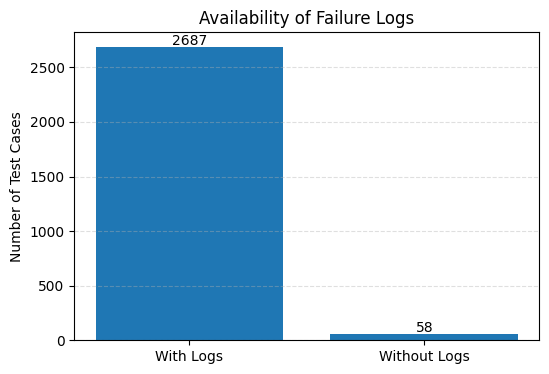

In [186]:
# ============================================================
# Step 5.1 - Analyse Failure Logs
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("FAILURE LOG ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Failure Log Availability
# ------------------------------------------------------------

has_logs = working_df["failure_log"].str.strip() != ""

total = len(working_df)
available = has_logs.sum()
empty = total - available

print(f"Total Test Cases      : {total}")
print(f"With Failure Logs     : {available} ({available/total*100:.2f}%)")
print(f"Without Failure Logs  : {empty} ({empty/total*100:.2f}%)")

# ------------------------------------------------------------
# Failure Log Length Statistics
# ------------------------------------------------------------

log_lengths = working_df["failure_log"].str.len()

summary = pd.DataFrame({

    "Metric":[
        "Mean Log Size",
        "Median Log Size",
        "95th Percentile",
        "Maximum Log Size"
    ],

    "Value":[
        round(log_lengths.mean(),2),
        int(log_lengths.median()),
        int(log_lengths.quantile(0.95)),
        int(log_lengths.max())
    ]

})

display(summary)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["With Logs","Without Logs"],
    [available, empty]
)

plt.ylabel("Number of Test Cases")
plt.title("Availability of Failure Logs")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+20,
        str(int(h)),
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## 5.2 Inspect Failure Log Structure
This step inspects representative failure logs to understand their internal structure before preprocessing.

The inspection identifies the common diagnostic components present within runtime failure logs, allowing preprocessing rules to be designed based on the actual dataset rather than assumptions.

### Expected Outcome

Identification of recurring runtime information such as:

- Exception types
- Exception messages
- Stack traces
- Assertion failures
- Retry information
- Maven/JUnit output

In [187]:
# ============================================================
# Step 5.2 - Inspect Failure Log Structure
# ============================================================

from IPython.display import display, Markdown

print("=" * 80)
print("FAILURE LOG STRUCTURE INSPECTION")
print("=" * 80)

# Select three representative non-empty failure logs
sample_logs = working_df[
    working_df["failure_log"].str.strip() != ""
].sample(
    n=3,
    random_state=42
)

for i, (_, row) in enumerate(sample_logs.iterrows(), start=1):

    display(Markdown(f"# Example {i}"))

    print(f"Test ID : {row['test_id']}")
    print(f"Log Size: {len(row['failure_log'])} characters\n")

    display(Markdown("### Failure Log"))

    display(
        Markdown(
            f"```text\n{row['failure_log']}\n```"
        )
    )

    display(Markdown("---"))

FAILURE LOG STRUCTURE INSPECTION


# Example 1

Test ID : Strutspluginsrestfe3b78etestObjectToXml
Log Size: 424 characters



### Failure Log

```text
Failed Rounds: 78/101
junit.framework.ComparisonFailure: expected:<<SimpleBean><[name>Jan</name><age>12</age><parents><parents>Adam</parents><parents>Ewa</parents></parents]></SimpleBean>> but was:<<SimpleBean><[parents><parents>Adam</parents><parents>Ewa</parents></parents><name>Jan</name><age>12</age]></SimpleBean>>
	at org.apache.struts2.rest.handler.JacksonXmlHandlerTest.testObjectToXml(JacksonXmlHandlerTest.java:66)
```

...

# Example 3

Test ID : ignite3modulestable19c8a82testApiTableManagerOnStop
Log Size: 131 characters



### Failure Log

```text
Failed Rounds: 76/101
java.lang.AssertionError: org.apache.ignite.internal.schema.configuration.index.TableIndexConfigurationSchema
```

---

### 5.3 Analyse Common Failure Log Patterns
This step analyses the entire collection of failure logs to identify common runtime patterns and potential non-informative artifacts before preprocessing.

The analysis is performed to ensure that preprocessing decisions are based on empirical evidence rather than assumptions.

### Justification

Failure logs are valuable runtime artifacts that contain diagnostic information relevant to flaky test classification. Before removing any content, the dataset is analysed to determine whether non-informative build logs, CI output, or benchmark metadata are present.

### Expected Outcome

Identification of:

- Benchmark execution metadata
- Build system messages
- Maven/Gradle output
- Exception information
- Stack traces
- Other recurring runtime patterns

In [188]:
# ============================================================
# Step 5.3 - Analyse Common Failure Log Patterns
# ============================================================

import re

print("=" * 80)
print("FAILURE LOG PATTERN ANALYSIS")
print("=" * 80)

patterns = {
    "Failed Rounds": r"Failed Rounds:",
    "AssertionError": r"AssertionError",
    "ComparisonFailure": r"ComparisonFailure",
    "Exception": r"Exception",
    "Caused by": r"Caused by:",
    "Stack Trace (at)": r"\bat\s+[\w.$]+",
    "BUILD FAILURE": r"BUILD FAILURE",
    "BUILD SUCCESS": r"BUILD SUCCESS",
    "Maven INFO": r"\[INFO\]",
    "Maven WARNING": r"\[WARNING\]",
    "Maven ERROR": r"\[ERROR\]",
    "Gradle": r"Gradle",
    "Tests run": r"Tests run:",
    "Time elapsed": r"Time elapsed",
    "Running": r"Running\s",
    "ANSI Escape Codes": r"\x1b\[[0-9;]*m"
}

results = []

logs = working_df["failure_log"].fillna("")

for name, pattern in patterns.items():

    count = logs.str.contains(
        pattern,
        regex=True,
        case=False
    ).sum()

    results.append({
        "Pattern": name,
        "Occurrences": count,
        "Percentage (%)": round(count / len(working_df) * 100, 2)
    })

pattern_df = pd.DataFrame(results)

display(pattern_df)

FAILURE LOG PATTERN ANALYSIS


,Pattern,Occurrences,Percentage (%)
0,Failed Rounds,2687,97.89
1,AssertionError,379,13.81
2,ComparisonFailure,483,17.60
3,Exception,723,26.34
4,Caused by,168,6.12
5,Stack Trace (at),2593,94.46
6,BUILD FAILURE,0,0.00
7,BUILD SUCCESS,0,0.00
8,Maven INFO,0,0.00
9,Maven WARNING,0,0.00


### Interpretation

The pattern analysis demonstrates that the failure logs are already highly curated and primarily consist of diagnostically relevant runtime information.

No build-system messages (e.g., Maven, Gradle, CI logs), ANSI escape sequences, or execution summaries were identified within the dataset.

The only consistently occurring non-runtime artifact is the benchmark-specific execution metadata (`Failed Rounds: X/Y`), which appears in **97.89%** of failure logs. Since this metadata reflects the repeated execution process used during dataset construction rather than the software failure itself, it is removed during preprocessing to reduce potential information leakage.

All exception types, assertion messages, stack traces, and causal chains are preserved because they represent essential diagnostic context for flaky test classification.

## 5.4 Apply Failure Log Normalization
This step applies minimal normalization to failure log artifacts.

Unlike Java source code, failure logs primarily consist of diagnostically relevant runtime information. Therefore, preprocessing is intentionally conservative.

The normalization removes only benchmark-specific execution metadata and formatting inconsistencies while preserving all runtime diagnostic information.

### Operations Performed

- Remove benchmark execution metadata (`Failed Rounds: X/Y`)
- Normalize line endings
- Remove trailing whitespace
- Collapse excessive blank lines

Exception types, assertion messages, stack traces, causal chains, and source code locations are preserved without modification.

### Expected Outcome

Failure logs retain all diagnostically relevant runtime information while eliminating benchmark-specific metadata that may introduce information leakage.

In [189]:
# ============================================================
# Step 5.4 - Apply Failure Log Normalization
# ============================================================

import re

print("=" * 80)
print("APPLY FAILURE LOG NORMALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Preserve original failure logs
# ------------------------------------------------------------

working_df["failure_log_original"] = working_df["failure_log"]


# ------------------------------------------------------------
# Failure log normalization
# ------------------------------------------------------------

def normalize_failure_log(log):

    if not isinstance(log, str):
        return log

    # Remove benchmark execution metadata
    log = re.sub(
        r"^Failed Rounds:\s*\d+/\d+\s*\n?",
        "",
        log,
        flags=re.MULTILINE
    )

    # Normalize line endings
    log = log.replace("\r\n", "\n").replace("\r", "\n")

    # Remove trailing whitespace
    log = "\n".join(line.rstrip() for line in log.splitlines())

    # Collapse excessive blank lines
    log = re.sub(r"\n{3,}", "\n\n", log)

    return log.strip()


# ------------------------------------------------------------
# Apply normalization
# ------------------------------------------------------------

working_df["failure_log"] = (
    working_df["failure_log"]
    .apply(normalize_failure_log)
)

print(f"Processed Records : {len(working_df)}")

print("\n✓ Failure log normalization completed successfully.")

APPLY FAILURE LOG NORMALIZATION
Processed Records : 2745

✓ Failure log normalization completed successfully.


### 5.5 Validate Failure Log Normalization
This step validates that failure log normalization removed only benchmark-specific metadata while preserving diagnostically relevant runtime information.

The validation confirms that:

- Benchmark execution metadata has been removed.
- Exception information is preserved.
- Stack traces are preserved.
- Failure logs remain non-empty after normalization.

In [190]:
# ============================================================
# Step 5.5 - Validate Failure Log Normalization
# ============================================================

print("=" * 80)
print("VALIDATE FAILURE LOG NORMALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Failed Rounds removed
# ------------------------------------------------------------

remaining_failed_rounds = (
    working_df["failure_log"]
    .str.contains("Failed Rounds:", regex=False)
    .sum()
)

print(f"Remaining 'Failed Rounds' Entries : {remaining_failed_rounds}")

# ------------------------------------------------------------
# Empty logs
# ------------------------------------------------------------

empty_logs = (
    working_df["failure_log"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"Empty Failure Logs               : {empty_logs}")

# ------------------------------------------------------------
# Stack traces preserved
# ------------------------------------------------------------

stack_traces = (
    working_df["failure_log"]
    .str.contains(r"\bat\s+[\w.$]+", regex=True)
    .sum()
)

print(f"Logs Containing Stack Traces     : {stack_traces}")

# ------------------------------------------------------------
# Exception information preserved
# ------------------------------------------------------------

exceptions = (
    working_df["failure_log"]
    .str.contains(
        r"(Exception|AssertionError|ComparisonFailure)",
        regex=True
    )
    .sum()
)

print(f"Logs Containing Exceptions       : {exceptions}")

assert remaining_failed_rounds == 0

print("\n✓ Validation passed successfully.")

VALIDATE FAILURE LOG NORMALIZATION
Remaining 'Failed Rounds' Entries : 0
Empty Failure Logs               : 58
Logs Containing Stack Traces     : 2593
Logs Containing Exceptions       : 1445

✓ Validation passed successfully.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17756\1247257414.py:52: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


In [191]:
# ============================================================
# Step 5.5 - Validate Failure Log Normalization
# ============================================================

print("=" * 80)
print("VALIDATE FAILURE LOG NORMALIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Validation 1 - Failed Rounds Removed
# ------------------------------------------------------------

remaining_failed_rounds = (
    working_df["failure_log"]
    .str.contains("Failed Rounds:", regex=False)
    .sum()
)

print(f"Remaining 'Failed Rounds' Entries : {remaining_failed_rounds}")

# ------------------------------------------------------------
# Validation 2 - Empty Failure Logs
# ------------------------------------------------------------

empty_logs = (
    working_df["failure_log"]
    .str.strip()
    .eq("")
    .sum()
)

print(f"Empty Failure Logs                : {empty_logs}")

# ------------------------------------------------------------
# Validation 3 - Stack Traces Preserved
# ------------------------------------------------------------

stack_traces = (
    working_df["failure_log"]
    .str.contains(r"\bat\s+[\w.$]+", regex=True)
    .sum()
)

print(f"Logs Containing Stack Traces      : {stack_traces}")

# ------------------------------------------------------------
# Validation 4 - Exception Information Preserved
# ------------------------------------------------------------

exceptions = (
    working_df["failure_log"]
    .str.contains(
        r"Exception|AssertionError|ComparisonFailure",
        regex=True
    )
    .sum()
)

print(f"Logs Containing Exceptions        : {exceptions}")

# ------------------------------------------------------------
# Validation 5 - Modified Failure Logs
# ------------------------------------------------------------

modified_logs = (
    working_df["failure_log_original"] !=
    working_df["failure_log"]
).sum()

print(f"Modified Failure Logs             : {modified_logs}")

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert remaining_failed_rounds == 0, "Failed Rounds metadata still exists."
assert stack_traces > 0, "Stack traces were unexpectedly removed."
assert exceptions > 0, "Exception information was unexpectedly removed."

print("\n✓ Validation passed successfully.")

VALIDATE FAILURE LOG NORMALIZATION
Remaining 'Failed Rounds' Entries : 0
Empty Failure Logs                : 58
Logs Containing Stack Traces      : 2593
Logs Containing Exceptions        : 1445
Modified Failure Logs             : 2687

✓ Validation passed successfully.


### 5.6 Quantify Normalization Effectiveness
This step quantitatively evaluates the impact of failure log normalization by comparing artifact sizes before and after preprocessing.

The evaluation measures the reduction in artifact size while ensuring that diagnostically relevant runtime information is preserved.

### Expected Outcome

A reduction in failure log size resulting primarily from the removal of benchmark-specific execution metadata and minor formatting normalization.

In [192]:
# ============================================================
# Step 5.6 - Quantify Failure Log Normalization
# ============================================================

print("=" * 80)
print("FAILURE LOG NORMALIZATION EFFECTIVENESS")
print("=" * 80)

before = working_df["failure_log_original"].str.len()

after = working_df["failure_log"].str.len()

reduction = before - after

modified = (
    working_df["failure_log_original"] !=
    working_df["failure_log"]
).sum()

summary = pd.DataFrame({

    "Metric":[
        "Mean Artifact Size Before",
        "Mean Artifact Size After",
        "Mean Size Reduction",
        "Overall Reduction (%)",
        "Modified Failure Logs",
        "Modification Rate (%)"
    ],

    "Value":[
        round(before.mean(),2),
        round(after.mean(),2),
        round(reduction.mean(),2),
        round((reduction.sum()/before.sum())*100,2),
        modified,
        round(modified/len(working_df)*100,2)
    ]

})

display(summary)

FAILURE LOG NORMALIZATION EFFECTIVENESS


,Metric,Value
0,Mean Artifact Size Before,3246.24
1,Mean Artifact Size After,3226.08
2,Mean Size Reduction,20.16
3,Overall Reduction (%),0.62
4,Modified Failure Logs,2687.00
5,Modification Rate (%),97.89


### Interpretation

Failure log normalization reduced the mean artifact size from **3246.24** to **3226.08** characters, corresponding to an overall reduction of **0.62%**.

Unlike source code artifacts, failure logs were intentionally subjected to minimal preprocessing because they primarily contain diagnostically relevant runtime information.

The reduction was achieved through the removal of benchmark-specific execution metadata (`Failed Rounds: X/Y`) and minor formatting normalization while preserving exception types, assertion messages, stack traces, causal chains, and source code locations.

This conservative preprocessing strategy minimizes information leakage while retaining the runtime context required for flaky test classification.

## 5.7 Before and After Comparison
This step presents representative examples illustrating the effect of failure log normalization.

Representative failure logs are displayed before and after preprocessing to qualitatively verify that only benchmark-specific execution metadata is removed while all diagnostically relevant runtime information is preserved.

The comparison demonstrates that exception types, assertion messages, stack traces, causal chains, and source code locations remain unchanged after preprocessing.

In [193]:
# ============================================================
# Step 5.7 - Before vs After Comparison
# ============================================================

from IPython.display import display, Markdown
import pandas as pd

print("=" * 80)
print("FAILURE LOG BEFORE VS AFTER")
print("=" * 80)

# ------------------------------------------------------------
# Select modified failure logs
# ------------------------------------------------------------

modified_df = working_df[
    working_df["failure_log_original"] !=
    working_df["failure_log"]
].copy()

sample_examples = modified_df.sample(
    n=min(3, len(modified_df)),
    random_state=42
)

print(f"Modified Failure Logs : {len(modified_df)}")
print(f"Displaying            : {len(sample_examples)} representative examples\n")

# ------------------------------------------------------------
# Display Examples
# ------------------------------------------------------------

for idx, (_, row) in enumerate(sample_examples.iterrows(), start=1):

    before = row["failure_log_original"]
    after = row["failure_log"]

    before_size = len(before)
    after_size = len(after)

    removed = before_size - after_size

    reduction = (
        removed / before_size * 100
        if before_size > 0 else 0
    )

    display(Markdown(f"# Example {idx}"))

    summary = pd.DataFrame({

        "Property":[
            "Test ID",
            "Original Size (Characters)",
            "Processed Size (Characters)",
            "Characters Removed",
            "Reduction (%)"
        ],

        "Value":[
            row["test_id"],
            before_size,
            after_size,
            removed,
            f"{reduction:.2f}%"
        ]

    })

    display(summary)

    display(Markdown("### Original Failure Log"))

    display(
        Markdown(
            f"```text\n{before}\n```"
        )
    )

    display(Markdown("### Normalized Failure Log"))

    display(
        Markdown(
            f"```text\n{after}\n```"
        )
    )

    display(Markdown("---"))

FAILURE LOG BEFORE VS AFTER
Modified Failure Logs : 2687
Displaying            : 3 representative examples



# Example 1

,Property,Value
0,Test ID,Strutspluginsrestfe3b78etestObjectToXml
1,Original Size (Characters),424
2,Processed Size (Characters),402
3,Characters Removed,22
4,Reduction (%),5.19%


### Original Failure Log

```text
Failed Rounds: 78/101
junit.framework.ComparisonFailure: expected:<<SimpleBean><[name>Jan</name><age>12</age><parents><parents>Adam</parents><parents>Ewa</parents></parents]></SimpleBean>> but was:<<SimpleBean><[parents><parents>Adam</parents><parents>Ewa</parents></parents><name>Jan</name><age>12</age]></SimpleBean>>
	at org.apache.struts2.rest.handler.JacksonXmlHandlerTest.testObjectToXml(JacksonXmlHandlerTest.java:66)
```

...

### Original Failure Log

```text
Failed Rounds: 76/101
java.lang.AssertionError: org.apache.ignite.internal.schema.configuration.index.TableIndexConfigurationSchema
```

### Normalized Failure Log

```text
java.lang.AssertionError: org.apache.ignite.internal.schema.configuration.index.TableIndexConfigurationSchema
```

---

# Step 6 - Code Under Test Preprocessing
This step analyses the production source code associated with each test case.

Unlike previous artifacts, the production code represents the largest contextual component of the dataset and therefore has the greatest impact on LLM prompt size.

Before designing a preprocessing strategy, the dataset is analysed to understand the availability and characteristics of production code artifacts.

### Scientific Justification

Production source code is substantially larger than test code, helper methods, and failure logs.

Consequently, preprocessing decisions must balance two competing objectives:

- Preserve sufficient implementation context for flaky test classification.
- Reduce unnecessary prompt length to improve LLM efficiency.

### Expected Outcome

A quantitative understanding of the production code artifacts before preprocessing.

CODE UNDER TEST ANALYSIS
Total Test Cases       : 2745
With Production Code   : 2740 (99.82%)
Without Production Code: 5 (0.18%)


,Metric,Value
0,Average Files per Test,10.94
1,Average Files (Non-empty),10.96
2,Median Files,4.00
3,Maximum Files,312.00


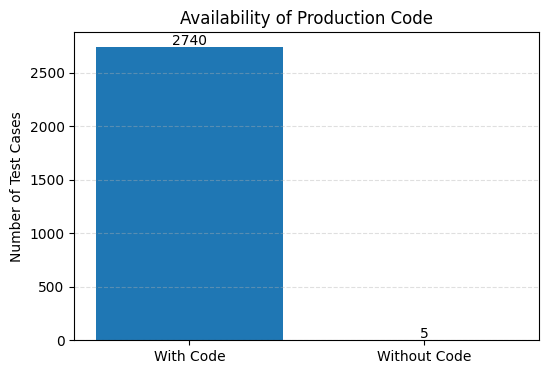

In [194]:
# ============================================================
# Step 6.1 - Analyse Code Under Test
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("CODE UNDER TEST ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# Availability
# ------------------------------------------------------------

has_code = working_df["code_under_test_json"].apply(
    lambda x: isinstance(x, dict) and len(x) > 0
)

total = len(working_df)
available = has_code.sum()
empty = total - available

print(f"Total Test Cases       : {total}")
print(f"With Production Code   : {available} ({available/total*100:.2f}%)")
print(f"Without Production Code: {empty} ({empty/total*100:.2f}%)")

# ------------------------------------------------------------
# Number of Files
# ------------------------------------------------------------

file_counts = working_df["code_under_test_json"].apply(
    lambda x: len(x) if isinstance(x, dict) else 0
)

non_empty_counts = file_counts[file_counts > 0]

summary = pd.DataFrame({

    "Metric":[
        "Average Files per Test",
        "Average Files (Non-empty)",
        "Median Files",
        "Maximum Files"
    ],

    "Value":[
        round(file_counts.mean(),2),
        round(non_empty_counts.mean(),2),
        int(non_empty_counts.median()),
        int(file_counts.max())
    ]

})

display(summary)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["With Code","Without Code"],
    [available, empty]
)

plt.ylabel("Number of Test Cases")
plt.title("Availability of Production Code")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+20,
        str(int(h)),
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## 6.2 Inspect Code Under Test Structure
This step inspects the internal structure of the `code_under_test_json` artifact.

The inspection identifies how production source code is organized, including the representation of source files and their associated implementations.

Understanding this structure is essential before designing a preprocessing and context selection strategy.

### Expected Outcome

Identification of:

- Production file paths
- Number of files
- Structure of the JSON artifact
- Representation of source code

In [195]:
# ============================================================
# Step 6.2 - Inspect Internal Structure
# ============================================================

from pprint import pprint

sample = working_df[
    working_df["code_under_test_json"].apply(
        lambda x: isinstance(x, dict) and len(x) > 0
    )
].iloc[0]

code_dict = sample["code_under_test_json"]

first_file = next(iter(code_dict))

print("=" * 80)
print("FIRST FILE")
print("=" * 80)

print(first_file)

print("\n")

print("=" * 80)
print("VALUE TYPE")
print("=" * 80)

print(type(code_dict[first_file]))

print("\n")

print("=" * 80)
print("VALUE CONTENT")
print("=" * 80)

pprint(code_dict[first_file])

FIRST FILE
com.ctrip.framework.apollo.openapi.client.service.AbstractOpenApiService


VALUE TYPE
<class 'dict'>


VALUE CONTENT
{'checkHttpResponseStatus': 'private void checkHttpResponseStatus(HttpResponse '
                            'response) {\n'
                            '    if (response.getStatusLine().getStatusCode() '
                            '== 200) {\n'
                            '      return;\n'
                            '    }\n'
                            '\n'
                            '    StatusLine status = '
                            'response.getStatusLine();\n'
                            '    String message = "";\n'
                            '    try {\n'
                            '      message = '
                            'EntityUtils.toString(response.getEntity());\n'
                            '    } catch (IOException e) {\n'
                            '      //ignore\n'
                            '    }\n'
                          

## 6.3 Characterize Production Code
This step characterizes the production source code associated with each test case.

The analysis measures the number of production classes, methods, and the total amount of source code provided as contextual information.

These statistics are used to design an appropriate context selection strategy before preprocessing.

In [196]:
# ============================================================
# Step 6.3 - Characterize Production Code
# ============================================================

print("=" * 80)
print("PRODUCTION CODE CHARACTERIZATION")
print("=" * 80)

# ------------------------------------------------------------
# Number of classes
# ------------------------------------------------------------

class_counts = working_df["code_under_test_json"].apply(
    lambda d: len(d) if isinstance(d, dict) else 0
)

# ------------------------------------------------------------
# Number of methods
# ------------------------------------------------------------

def count_methods(code_dict):

    if not isinstance(code_dict, dict):
        return 0

    total = 0

    for cls in code_dict.values():

        if isinstance(cls, dict):
            total += len(cls)

    return total

method_counts = working_df["code_under_test_json"].apply(
    count_methods
)

# ------------------------------------------------------------
# Total source code size
# ------------------------------------------------------------

def total_code_size(code_dict):

    if not isinstance(code_dict, dict):
        return 0

    total = 0

    for cls in code_dict.values():

        if isinstance(cls, dict):

            total += sum(
                len(code)
                for code in cls.values()
                if isinstance(code, str)
            )

    return total

code_sizes = working_df["code_under_test_json"].apply(
    total_code_size
)

summary = pd.DataFrame({

    "Metric":[
        "Average Classes",
        "Maximum Classes",
        "Average Methods",
        "Maximum Methods",
        "Average Characters",
        "Maximum Characters"
    ],

    "Value":[
        round(class_counts.mean(),2),
        int(class_counts.max()),
        round(method_counts.mean(),2),
        int(method_counts.max()),
        round(code_sizes.mean(),2),
        int(code_sizes.max())
    ]

})

display(summary)

PRODUCTION CODE CHARACTERIZATION


,Metric,Value
0,Average Classes,10.94
1,Maximum Classes,312.00
2,Average Methods,54.19
3,Maximum Methods,1483.00
4,Average Characters,25068.38
5,Maximum Characters,1479667.00


## 6.4 Production Code Size Distribution
This step analyses the distribution of production code artifact sizes across the dataset.

While previous analyses reported average and maximum sizes, this step examines the overall distribution to determine whether extremely large production code artifacts are common or limited to a small number of outliers.

The resulting statistics provide empirical evidence for understanding the scalability of the dataset and for discussing LLM context limitations in later experiments.

### Expected Outcome

- Distribution of production code sizes.
- Percentage of test cases within different size ranges.
- Identification of large production code outliers.

PRODUCTION CODE SIZE DISTRIBUTION


,Production Code Size,Test Cases,Percentage (%)
0,<10K,1796,65.43
1,10K–25K,302,11.00
2,25K–50K,303,11.04
3,50K–100K,215,7.83
4,100K–250K,96,3.50
5,>250K,33,1.20


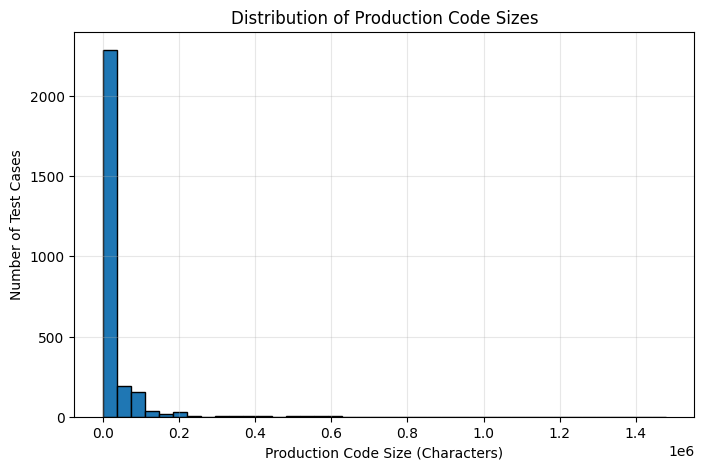

In [197]:
# ============================================================
# Step 6.4 - Production Code Size Distribution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("PRODUCTION CODE SIZE DISTRIBUTION")
print("=" * 80)

# ------------------------------------------------------------
# Production code size (already calculated in Step 6.3)
# ------------------------------------------------------------

sizes = working_df["code_under_test_json"].apply(total_code_size)

# ------------------------------------------------------------
# Size Categories
# ------------------------------------------------------------

bins = [0, 10000, 25000, 50000, 100000, 250000, np.inf]

labels = [
    "<10K",
    "10K–25K",
    "25K–50K",
    "50K–100K",
    "100K–250K",
    ">250K"
]

distribution = pd.cut(
    sizes,
    bins=bins,
    labels=labels,
    include_lowest=True
).value_counts().sort_index()

summary = pd.DataFrame({
    "Production Code Size": distribution.index.astype(str),
    "Test Cases": distribution.values,
    "Percentage (%)": (
        distribution.values / len(working_df) * 100
    ).round(2)
})

display(summary)

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    sizes,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Production Code Size (Characters)")
plt.ylabel("Number of Test Cases")
plt.title("Distribution of Production Code Sizes")

plt.grid(alpha=0.3)

plt.show()

### Key observations
76.43% (65.43% + 11.00%) of test cases contain less than 25K characters of production code.
87.47% contain less than 50K characters.
Only 1.20% are extremely large (>250K characters).

This tells us that the dataset is not dominated by massive production code. Instead, there is a small number of extreme outliers that produce the maximum size of nearly 1.5 million characters.

## 6.5 Apply Production Code Cleaning
This step applies lexical preprocessing to the production source code associated with each test case.

The preprocessing is performed at the individual method level while preserving the original hierarchical structure of the production code (Class → Method → Source Code).

### Operations Performed

- Remove Javadoc comments.
- Remove block comments.
- Remove single-line comments.
- Remove trailing whitespace.
- Collapse excessive blank lines.

No production classes or methods are removed during preprocessing. The original contextual information is preserved while improving textual consistency and reducing unnecessary prompt length.

### Expected Outcome

A cleaned production code artifact with reduced lexical noise while preserving all implementation logic and structural relationships.

In [198]:
# ============================================================
# Step 6.5 - Apply Production Code Cleaning
# ============================================================

import re

print("=" * 80)
print("APPLY PRODUCTION CODE CLEANING")
print("=" * 80)

# ------------------------------------------------------------
# Preserve original production code
# ------------------------------------------------------------

working_df["code_under_test_original"] = working_df["code_under_test_json"]

# ------------------------------------------------------------
# Dataset-specific normalization
# ------------------------------------------------------------

def remove_orphan_javadoc(code):
    """
    Removes orphaned Javadoc fragments that appear at the beginning
    of extracted production methods when the opening '/**' delimiter
    is missing due to dataset extraction.

    Example:

    e<sup>m</sup>
     * @param ...
     * @return ...
     */
    public static ...

    becomes

    public static ...
    """

    if not isinstance(code, str):
        return code

    lines = code.splitlines()

    cleaned = []

    skipping = True
    found_end = False

    for line in lines:

        stripped = line.strip()

        if skipping:

            # Skip HTML description lines
            if "<sup>" in stripped or "</sup>" in stripped or "<p>" in stripped or "</p>" in stripped:
                continue

            # Skip orphaned Javadoc lines
            if stripped.startswith("*"):
                continue

            # Skip closing */
            if stripped == "*/":
                found_end = True
                continue

            # First real code line
            skipping = False

        cleaned.append(line)

    return "\n".join(cleaned).strip()


# ------------------------------------------------------------
# Clean production code
# ------------------------------------------------------------

def preprocess_code_under_test(code_dict):

    if not isinstance(code_dict, dict):
        return code_dict

    cleaned_classes = {}

    for class_name, methods in code_dict.items():

        if not isinstance(methods, dict):
            cleaned_classes[class_name] = methods
            continue

        cleaned_methods = {}

        for method_name, method_code in methods.items():

            if isinstance(method_code, str):

                # General Java preprocessing
                cleaned = clean_java_code(method_code)

                # Dataset-specific normalization
                cleaned = remove_orphan_javadoc(cleaned)

                cleaned_methods[method_name] = cleaned

            else:
                cleaned_methods[method_name] = method_code

        cleaned_classes[class_name] = cleaned_methods

    return cleaned_classes


# ------------------------------------------------------------
# Apply preprocessing
# ------------------------------------------------------------

working_df["code_under_test_json"] = (
    working_df["code_under_test_json"]
    .apply(preprocess_code_under_test)
)

print(f"Processed Records : {len(working_df)}")

print("\n✓ Production code preprocessing completed successfully.")

APPLY PRODUCTION CODE CLEANING
Processed Records : 2745

✓ Production code preprocessing completed successfully.


## 6.6 Validate Production Code Preprocessing
This step validates that production code preprocessing preserves the original hierarchical structure and implementation logic while removing only lexical noise.

The validation confirms that:

- The number of production classes is preserved.
- The number of methods is preserved.
- No empty methods are introduced.
- Production code remains available after preprocessing.

### Expected Outcome

The preprocessing should preserve all production classes and methods while reducing only comments and formatting-related artifacts.

In [199]:
# ============================================================
# Step 6.6 - Validate Production Code Preprocessing
# ============================================================

print("=" * 80)
print("VALIDATE PRODUCTION CODE PREPROCESSING")
print("=" * 80)

# ------------------------------------------------------------
# Count classes
# ------------------------------------------------------------

def class_count(code_dict):
    if not isinstance(code_dict, dict):
        return 0
    return len(code_dict)

# ------------------------------------------------------------
# Count methods
# ------------------------------------------------------------

def method_count(code_dict):

    if not isinstance(code_dict, dict):
        return 0

    total = 0

    for methods in code_dict.values():
        if isinstance(methods, dict):
            total += len(methods)

    return total

# ------------------------------------------------------------
# Count empty methods
# ------------------------------------------------------------

def empty_method_count(code_dict):

    if not isinstance(code_dict, dict):
        return 0

    total = 0

    for methods in code_dict.values():

        if isinstance(methods, dict):

            for code in methods.values():

                if isinstance(code, str) and len(code.strip()) == 0:
                    total += 1

    return total

# ------------------------------------------------------------
# Validation Metrics
# ------------------------------------------------------------

original_classes = working_df["code_under_test_original"].apply(class_count)
processed_classes = working_df["code_under_test_json"].apply(class_count)

original_methods = working_df["code_under_test_original"].apply(method_count)
processed_methods = working_df["code_under_test_json"].apply(method_count)

empty_methods = working_df["code_under_test_json"].apply(empty_method_count).sum()

print(f"Class Count Preserved  : {(original_classes == processed_classes).all()}")
print(f"Method Count Preserved : {(original_methods == processed_methods).all()}")
print(f"Empty Methods          : {empty_methods}")

assert (original_classes == processed_classes).all()
assert (original_methods == processed_methods).all()

print("\n✓ Validation passed successfully.")

VALIDATE PRODUCTION CODE PREPROCESSING
Class Count Preserved  : True
Method Count Preserved : True
Empty Methods          : 0

✓ Validation passed successfully.


## 6.7 Quantify Cleaning Effectiveness
This step quantifies the impact of production code preprocessing by comparing artifact sizes before and after cleaning.

The evaluation measures the reduction in lexical noise while confirming that all production classes and methods are preserved.

In [200]:
# ============================================================
# Step 6.7 - Quantify Production Code Cleaning
# ============================================================

print("=" * 80)
print("PRODUCTION CODE CLEANING EFFECTIVENESS")
print("=" * 80)

# ------------------------------------------------------------
# Calculate total size
# ------------------------------------------------------------

def total_size(code_dict):

    if not isinstance(code_dict, dict):
        return 0

    total = 0

    for methods in code_dict.values():

        if isinstance(methods, dict):

            total += sum(
                len(code)
                for code in methods.values()
                if isinstance(code, str)
            )

    return total

before = working_df["code_under_test_original"].apply(total_size)
after = working_df["code_under_test_json"].apply(total_size)

reduction = before - after

modified = (
    working_df["code_under_test_original"] !=
    working_df["code_under_test_json"]
).sum()

summary = pd.DataFrame({

    "Metric":[
        "Mean Artifact Size Before",
        "Mean Artifact Size After",
        "Mean Size Reduction",
        "Overall Reduction (%)",
        "Modified Production Code Artifacts",
        "Modification Rate (%)"
    ],

    "Value":[
        round(before.mean(),2),
        round(after.mean(),2),
        round(reduction.mean(),2),
        round((reduction.sum()/before.sum())*100,2),
        modified,
        round(modified/len(working_df)*100,2)
    ]

})

display(summary)

PRODUCTION CODE CLEANING EFFECTIVENESS


,Metric,Value
0,Mean Artifact Size Before,25068.38
1,Mean Artifact Size After,20801.45
2,Mean Size Reduction,4266.93
3,Overall Reduction (%),17.02
4,Modified Production Code Artifacts,2520.00
5,Modification Rate (%),91.80


## 6.8 Before and After Comparison
This step presents representative examples illustrating the effect of production code preprocessing.

A representative production class and one of its methods are displayed before and after preprocessing to demonstrate that only lexical artifacts (comments and formatting) were removed while preserving the implementation logic.

### Expected Outcome

The comparison should demonstrate that production code semantics remain unchanged while comments and redundant whitespace are removed.

In [201]:
# ============================================================
# Step 6.8 - Before vs After Comparison
# ============================================================

from IPython.display import display, Markdown
import pandas as pd

print("=" * 80)
print("PRODUCTION CODE BEFORE VS AFTER")
print("=" * 80)

# ------------------------------------------------------------
# Find modified production code artifacts
# ------------------------------------------------------------

modified_df = working_df[
    working_df["code_under_test_original"] !=
    working_df["code_under_test_json"]
].copy()

sample_examples = modified_df.sample(
    n=min(3, len(modified_df)),
    random_state=42
)

print(f"Modified Production Code Artifacts : {len(modified_df)}")
print(f"Displaying                         : {len(sample_examples)} representative examples\n")

# ------------------------------------------------------------
# Display examples
# ------------------------------------------------------------

for idx, (_, row) in enumerate(sample_examples.iterrows(), start=1):

    original = row["code_under_test_original"]
    processed = row["code_under_test_json"]

    class_name = None
    method_name = None
    before = None
    after = None

    # --------------------------------------------------------
    # Find a method that actually changed
    # --------------------------------------------------------

    found = False

    for cls_name, methods in original.items():

        if not isinstance(methods, dict):
            continue

        processed_methods = processed.get(cls_name, {})

        for m_name, original_code in methods.items():

            processed_code = processed_methods.get(m_name, "")

            if original_code != processed_code:

                class_name = cls_name
                method_name = m_name
                before = original_code
                after = processed_code

                found = True
                break

        if found:
            break

    # --------------------------------------------------------
    # Fallback (should rarely happen)
    # --------------------------------------------------------

    if not found:

        class_name = next(iter(original.keys()))

        method_name = next(iter(original[class_name].keys()))

        before = original[class_name][method_name]
        after = processed[class_name][method_name]

    removed = len(before) - len(after)

    reduction = (
        removed / len(before) * 100
        if len(before) else 0
    )

    display(Markdown(f"# Example {idx}"))

    summary = pd.DataFrame({

        "Property": [
            "Test ID",
            "Production Class",
            "Method",
            "Original Size",
            "Processed Size",
            "Characters Removed",
            "Reduction (%)"
        ],

        "Value": [
            row["test_id"],
            class_name,
            method_name,
            len(before),
            len(after),
            removed,
            f"{reduction:.2f}%"
        ]

    })

    display(summary)

    display(Markdown("### Original Method"))

    display(
        Markdown(
            f"```java\n{before[:1500]}\n```"
        )
    )

    if len(before) > 1500:
        display(Markdown("*Output truncated for readability.*"))

    display(Markdown("### Preprocessed Method"))

    display(
        Markdown(
            f"```java\n{after[:1500]}\n```"
        )
    )

    if len(after) > 1500:
        display(Markdown("*Output truncated for readability.*"))

    display(Markdown("---"))

PRODUCTION CODE BEFORE VS AFTER
Modified Production Code Artifacts : 2520
Displaying                         : 3 representative examples



# Example 1

,Property,Value
0,Test ID,jsonio01f83batestNewArrayElement
1,Production Class,Person
2,Method,<init>
3,Original Size,38
4,Processed Size,18
5,Characters Removed,20
6,Reduction (%),52.63%


### Original Method

```java
// Constructors
    public Person() {}
```

...

*Output truncated for readability.*

### Preprocessed Method

```java
@Override
  public FlowScope getPreciserScopeKnowingConditionOutcome(Node condition,
      FlowScope blindScope, boolean outcome) {

    int operatorToken = condition.getType();
    switch (operatorToken) {
      case Token.EQ:
      case Token.NE:
      case Token.SHEQ:
      case Token.SHNE:
      case Token.CASE:
        Node left;
        Node right;
        if (operatorToken == Token.CASE) {
          left = condition.getParent().getFirstChild();
          right = condition.getFirstChild();
        } else {
          left = condition.getFirstChild();
          right = condition.getLastChild();
        }

        Node typeOfNode = null;
        Node stringNode = null;
        if (left.isTypeOf() && right.isString()) {
          typeOfNode = left;
          stringNode = right;
        } else if (right.isTypeOf() &&
                   left.isString()) {
          typeOfNode = right;
          stringNode = left;
        }
        if (typeOfNode != null && stringNode != null) {
          Node operandNode = typeOfNode.getFirstChild();
          JSType operandType = getTypeIfRefinable(operandNode, blindScope);
          if (operandType != null) {
            boolean resultEqualsValue = operatorToken == Token.EQ ||
                operatorToken == Token.SHEQ || operatorToken == Token.CASE;
            if (!outcome) {
              resultEqualsValue = !resultEqualsValue;
            }
            return caseTypeOf(operandNode, operandType, stringNode.getString(),
                
```

*Output truncated for readability.*

---

# 7. Final Dataset Validation

## 7.1 Validate Dataset Integrity
This step performs a final integrity check of the preprocessed dataset to ensure that no records were unintentionally lost or duplicated during preprocessing.

The validation verifies:

- Dataset size
- Duplicate test identifiers
- Missing values in required contextual artifacts

### Expected Outcome

The dataset should remain structurally complete and ready for experimentation.

In [202]:
# ============================================================
# Step 7.1 - Validate Dataset Integrity
# ============================================================

print("=" * 80)
print("FINAL DATASET INTEGRITY")
print("=" * 80)

print(f"Dataset Size : {len(working_df)}")

duplicates = working_df["test_id"].duplicated().sum()

print(f"Duplicate Test IDs : {duplicates}")

required_columns = [
    "test_id",
    "test_code",
    "helper_methods_json",
    "failure_log",
    "code_under_test_json"
]

missing = working_df[required_columns].isna().sum()

summary = pd.DataFrame({

    "Column": missing.index,
    "Missing Values": missing.values

})

display(summary)

assert duplicates == 0

print("\n✓ Dataset integrity validation passed.")

FINAL DATASET INTEGRITY
Dataset Size : 2745
Duplicate Test IDs : 0


,Column,Missing Values
0,test_id,0
1,test_code,0
2,helper_methods_json,0
3,failure_log,0
4,code_under_test_json,0



✓ Dataset integrity validation passed.


## 7.2 Validate Context Artifacts
This step validates the availability of every contextual artifact after preprocessing.

The validation confirms that contextual information remains available for later prompt construction.

In [203]:
# ============================================================
# Step 7.2 - Validate Context Artifacts
# ============================================================

print("=" * 80)
print("CONTEXT ARTIFACT VALIDATION")
print("=" * 80)

summary = pd.DataFrame({

    "Context Artifact":[
        "Test Code",
        "Helper Methods",
        "Failure Log",
        "Code Under Test"
    ],

    "Available":[

        (working_df["test_code"].str.strip() != "").sum(),

        working_df["helper_methods_json"].apply(
            lambda x: isinstance(x, dict) and len(x) > 0
        ).sum(),

        (working_df["failure_log"].str.strip() != "").sum(),

        working_df["code_under_test_json"].apply(
            lambda x: isinstance(x, dict) and len(x) > 0
        ).sum()

    ]

})

summary["Missing"] = len(working_df) - summary["Available"]

summary["Availability (%)"] = (

    summary["Available"] /
    len(working_df) * 100

).round(2)

display(summary)

print("\n✓ Context artifact validation completed.")

CONTEXT ARTIFACT VALIDATION


,Context Artifact,Available,Missing,Availability (%)
0,Test Code,2745,0,100.00
1,Helper Methods,1411,1334,51.40
2,Failure Log,2687,58,97.89
3,Code Under Test,2740,5,99.82



✓ Context artifact validation completed.


## 7.3 Final Dataset Summary
This step summarizes the final characteristics of the preprocessed dataset before export.

The summary provides an overview of dataset size and contextual artifact availability.

In [204]:
# ============================================================
# Step 7.3 - Final Dataset Summary
# ============================================================

print("=" * 80)
print("FINAL DATASET SUMMARY")
print("=" * 80)

summary = pd.DataFrame({

    "Metric":[
        "Total Test Cases",
        "Test Code Available",
        "Helper Methods Available",
        "Failure Logs Available",
        "Production Code Available"
    ],

    "Value":[
        len(working_df),

        (working_df["test_code"].str.strip() != "").sum(),

        working_df["helper_methods_json"].apply(
            lambda x: isinstance(x, dict) and len(x) > 0
        ).sum(),

        (working_df["failure_log"].str.strip() != "").sum(),

        working_df["code_under_test_json"].apply(
            lambda x: isinstance(x, dict) and len(x) > 0
        ).sum()

    ]

})

display(summary)

FINAL DATASET SUMMARY


,Metric,Value
0,Total Test Cases,2745
1,Test Code Available,2745
2,Helper Methods Available,1411
3,Failure Logs Available,2687
4,Production Code Available,2740


## 7.4 Dataset Ready Confirmation
This final validation confirms that preprocessing has completed successfully and that the resulting dataset is ready for prompt construction and LLM evaluation experiments.

In [205]:
# ============================================================
# Step 7.4 - Dataset Ready Confirmation
# ============================================================

print("=" * 80)
print("DATASET READY")
print("=" * 80)

print("✓ Dataset refinement completed")

print("✓ Test code preprocessed")

print("✓ Helper methods preprocessed")

print("✓ Failure logs normalized")

print("✓ Production code preprocessed")

print("\nFinal Dataset Size :", len(working_df))

print("\n✓ Preprocessed dataset is ready for export.")

DATASET READY
✓ Dataset refinement completed
✓ Test code preprocessed
✓ Helper methods preprocessed
✓ Failure logs normalized
✓ Production code preprocessed

Final Dataset Size : 2745

✓ Preprocessed dataset is ready for export.


# 8. Dataset Visualization

## 8.1 Class Distribution

This section visualizes the class distribution of the preprocessed dataset.

The visualization confirms whether the dataset is balanced between flaky and non-flaky test cases.

CLASS DISTRIBUTION


,Class,Count,Percentage (%)
0,Non-Flaky,1638,59.67
1,Flaky,1107,40.33


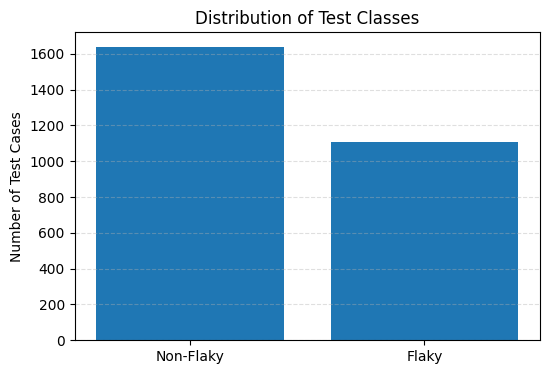

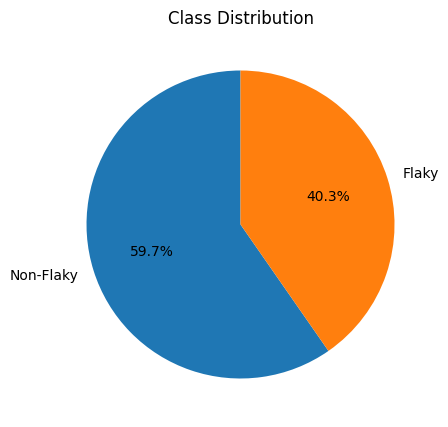

In [206]:
# ============================================================
# Step 8.1 - Class Distribution
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)

# ------------------------------------------------------------
# Count classes
# ------------------------------------------------------------

class_counts = (
    working_df["isFlaky"]
    .value_counts()
    .rename(index={
        True: "Flaky",
        False: "Non-Flaky"
    })
)

summary = pd.DataFrame({

    "Class": class_counts.index,
    "Count": class_counts.values

})

summary["Percentage (%)"] = (
    summary["Count"] /
    len(working_df) * 100
).round(2)

display(summary)

# ------------------------------------------------------------
# Bar Chart
# ------------------------------------------------------------

plt.figure(figsize=(6,4))

plt.bar(
    summary["Class"],
    summary["Count"]
)

plt.title("Distribution of Test Classes")

plt.ylabel("Number of Test Cases")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# ------------------------------------------------------------
# Pie Chart
# ------------------------------------------------------------

plt.figure(figsize=(5,5))

plt.pie(
    summary["Count"],
    labels=summary["Class"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution")

plt.show()

## 8.2 Context Artifact Availability
This section visualizes the availability of each contextual artifact after preprocessing.

The visualization highlights the completeness of contextual information available for LLM prompt construction.

CONTEXT ARTIFACT AVAILABILITY


,Artifact,Available,Percentage (%)
0,Test Code,2745,100.00
1,Helper Methods,1411,51.40
2,Failure Logs,2687,97.89
3,Code Under Test,2740,99.82


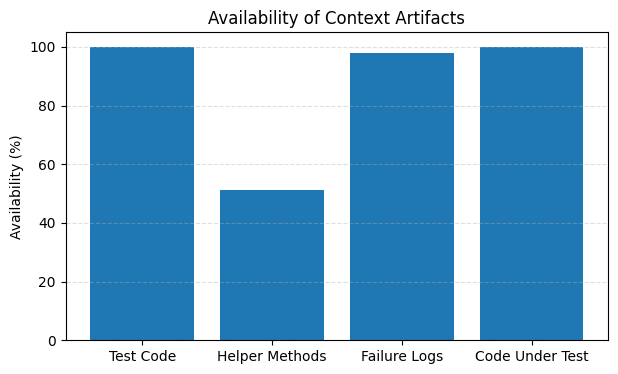

In [207]:
# ============================================================
# Step 8.2 - Context Artifact Availability
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("=" * 80)
print("CONTEXT ARTIFACT AVAILABILITY")
print("=" * 80)

availability = pd.DataFrame({

    "Artifact":[
        "Test Code",
        "Helper Methods",
        "Failure Logs",
        "Code Under Test"
    ],

    "Available":[
        (working_df["test_code"].str.strip() != "").sum(),

        working_df["helper_methods_json"].apply(
            lambda x: isinstance(x, dict) and len(x) > 0
        ).sum(),

        (working_df["failure_log"].str.strip() != "").sum(),

        working_df["code_under_test_json"].apply(
            lambda x: isinstance(x, dict) and len(x) > 0
        ).sum()
    ]

})

availability["Percentage (%)"] = (
    availability["Available"] /
    len(working_df) * 100
).round(2)

display(availability)

plt.figure(figsize=(7,4))

plt.bar(
    availability["Artifact"],
    availability["Percentage (%)"]
)

plt.ylabel("Availability (%)")
plt.ylim(0,105)

plt.title("Availability of Context Artifacts")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## 8.3 Average Context Size
This section compares the average size of each contextual artifact after preprocessing.

Artifact size is measured in characters.

AVERAGE CONTEXT SIZE


,Artifact,Average Characters
0,Test Code,711
1,Helper Methods,281
2,Failure Log,3226
3,Production Code,20801


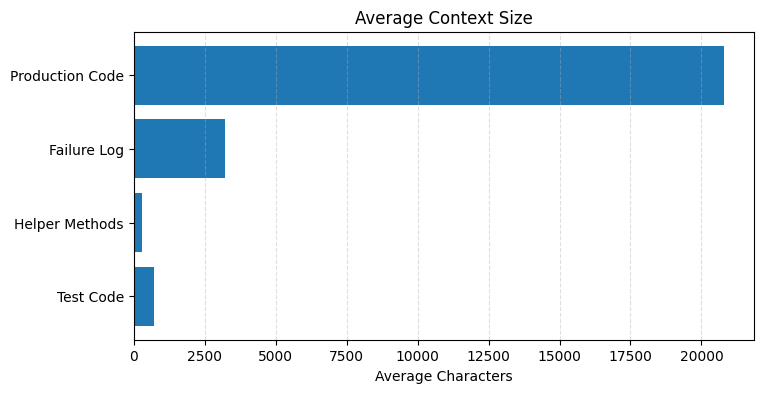

In [208]:
# ============================================================
# Step 8.3 - Average Context Size
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("AVERAGE CONTEXT SIZE")
print("=" * 80)

helper_sizes = working_df["helper_methods_json"].apply(
    lambda x: sum(len(v) for v in x.values())
    if isinstance(x, dict) else 0
)

production_sizes = working_df["code_under_test_json"].apply(
    lambda x: sum(
        len(method)
        for methods in x.values()
        if isinstance(methods, dict)
        for method in methods.values()
    ) if isinstance(x, dict) else 0
)

summary = pd.DataFrame({

    "Artifact":[
        "Test Code",
        "Helper Methods",
        "Failure Log",
        "Production Code"
    ],

    "Average Characters":[

        working_df["test_code"].str.len().mean(),

        helper_sizes.mean(),

        working_df["failure_log"].str.len().mean(),

        production_sizes.mean()

    ]

})

summary["Average Characters"] = (
    summary["Average Characters"]
    .round(0)
    .astype(int)
)

display(summary)

plt.figure(figsize=(8,4))

plt.barh(
    summary["Artifact"],
    summary["Average Characters"]
)

plt.xlabel("Average Characters")

plt.title("Average Context Size")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

## 8.4 Production Code Size Distribution
This section illustrates the distribution of production code sizes across the dataset.

The figure highlights the presence of both small and large production contexts.

PRODUCTION CODE SIZE DISTRIBUTION


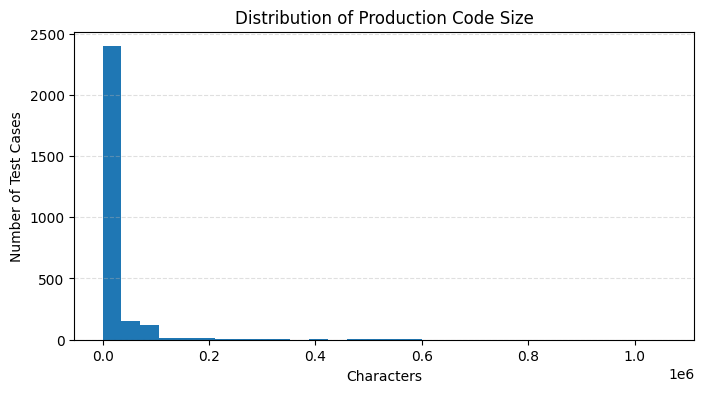

In [209]:
# ============================================================
# Step 8.4 - Production Code Size Distribution
# ============================================================

import matplotlib.pyplot as plt

print("=" * 80)
print("PRODUCTION CODE SIZE DISTRIBUTION")
print("=" * 80)

plt.figure(figsize=(8,4))

plt.hist(
    production_sizes,
    bins=30
)

plt.xlabel("Characters")

plt.ylabel("Number of Test Cases")

plt.title("Distribution of Production Code Size")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

## 8.5 Correlation Between Context Sources
This section examines the relationships between the sizes of different contextual artifacts.

The correlation matrix helps identify whether larger test cases tend to be associated with larger contextual information.

CONTEXT SIZE CORRELATION


,Test Code,Helper Methods,Failure Log,Production Code
Test Code,1.00,0.09,-0.05,0.07
Helper Methods,0.09,1.00,-0.03,0.14
Failure Log,-0.05,-0.03,1.00,-0.04
Production Code,0.07,0.14,-0.04,1.00


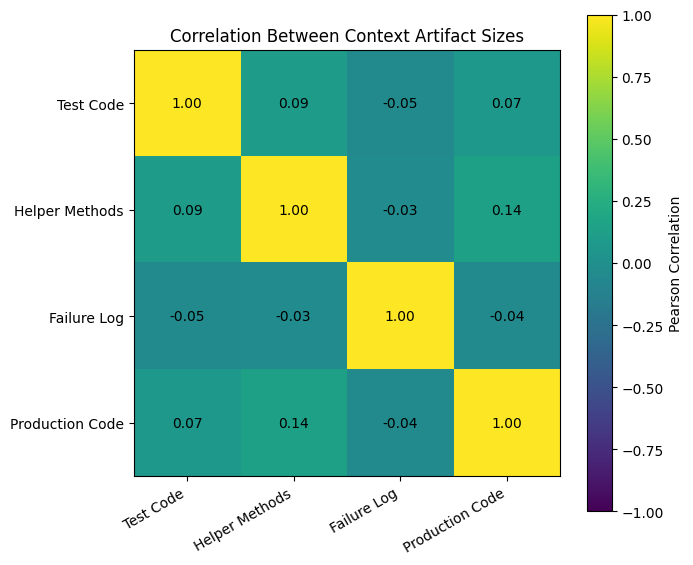

In [210]:
# ============================================================
# Step 8.5 - Correlation Between Context Sources
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 80)
print("CONTEXT SIZE CORRELATION")
print("=" * 80)

corr_df = pd.DataFrame({

    "Test Code":
        working_df["test_code"].str.len(),

    "Helper Methods":
        helper_sizes,

    "Failure Log":
        working_df["failure_log"].str.len(),

    "Production Code":
        production_sizes

})

correlation = corr_df.corr()

display(correlation.round(2))

plt.figure(figsize=(7,6))

im = plt.imshow(
    correlation,
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Show correlation values
for i in range(len(correlation)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.colorbar(im, label="Pearson Correlation")

plt.title("Correlation Between Context Artifact Sizes")

plt.tight_layout()

plt.show()

## This supports the observation that the contextual artifacts provide complementary information rather than redundant information.

# 9. Export Preprocessed Dataset

## 9.1 Export Dataset

### Objective

This step exports the fully preprocessed context-augmented dataset for use in prompt engineering and LLM evaluation experiments.

The dataset is exported in JSON Lines (`.jsonl`) format, which preserves the nested JSON structure of contextual artifacts such as helper methods and production code without requiring additional serialization.

### Output

The exported dataset is saved as:

- `context_augmented_dataset_preprocessed.jsonl`

In [211]:
# ============================================================
# Step 9.1 - Export Preprocessed Dataset
# ============================================================

from pathlib import Path

print("=" * 80)
print("EXPORT PREPROCESSED DATASET")
print("=" * 80)

# ------------------------------------------------------------
# Output Path
# ------------------------------------------------------------

OUTPUT_PATH = Path("context_augmented_dataset_preprocessed.jsonl")

# ------------------------------------------------------------
# Export Dataset
# ------------------------------------------------------------

working_df.to_json(
    OUTPUT_PATH,
    orient="records",
    lines=True,
    force_ascii=False
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(f"Dataset exported successfully.")

print(f"\nLocation : {OUTPUT_PATH.resolve()}")

print(f"\nTotal Records Exported : {len(working_df)}")

print("\n✓ Export completed successfully.")

EXPORT PREPROCESSED DATASET
Dataset exported successfully.

Location : D:\university works\Final-Year_Firts_sem\FYP\INFO\REPO\CA-Classification-Framework\data-preprocess\context_augmented_dataset_preprocessed.jsonl

Total Records Exported : 2745

✓ Export completed successfully.


## 9.2 Verify Export

### Objective

This step verifies that the exported dataset can be successfully reloaded without data loss.

The validation confirms that the exported dataset preserves both the number of records and the dataset schema.

### Expected Outcome

The exported dataset should contain the same number of records and columns as the in-memory preprocessed dataset.

In [212]:
# ============================================================
# Step 9.2 - Verify Export
# ============================================================

print("=" * 80)
print("VERIFY EXPORTED DATASET")
print("=" * 80)

# ------------------------------------------------------------
# Reload Exported Dataset
# ------------------------------------------------------------

export_df = pd.read_json(
    OUTPUT_PATH,
    lines=True
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print(f"Original Dataset Size : {len(working_df)}")
print(f"Exported Dataset Size : {len(export_df)}")

print(f"\nOriginal Columns : {len(working_df.columns)}")
print(f"Exported Columns : {len(export_df.columns)}")

assert len(export_df) == len(working_df)
assert list(export_df.columns) == list(working_df.columns)

print("\n✓ Export verification passed successfully.")

VERIFY EXPORTED DATASET
Original Dataset Size : 2745
Exported Dataset Size : 2745

Original Columns : 15
Exported Columns : 15

✓ Export verification passed successfully.
